In [104]:
library(limma)
library(parallel)
library(ggplot2)
library(UpSetR)

In [11]:
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/DEG_study_metadata_remob.csv",header = T)

In [12]:
head(metadata)

,study,species,stress,path.to.candidate.genes,CDS.fa
,<chr>,<chr>,<chr>,<chr>,<chr>
1,Huertas et al. 2024,Panicum virgatum,remob,output/candidateGenes_remob/lowN_huertas2024.list,Pvirgatum_450_v4.1.cds_primaryTranscriptOnly.fa.gz
2,Yang et al. 2016,Panicum virgatum,remob,output/candidateGenes_remob/remob_yang2016.list,Zea_mays.AGPv3.22.cdna.all.fa.gz
3,Torres-Rodriguez et al. 2021,Zea mays,remob,output/candidateGenes_remob/lowNP_torres2021.list,Zea_mays.AGPv3.22.cdna.all.fa.gz
4,Sekhon et al. 2019,Zea mays,remob,output/candidateGenes_remob/remob_sekhon2019.list,Zm-B73-REFERENCE-GRAMENE-4.0_Zm00001d.2.cds.fa.gz
5,Mitros et al. 2020,Miscanthus giganteus,remob,output/candidateGenes_remob/remob_mitros2020.list,Msinensis_497_v7.1.cds_primaryTranscriptOnly.fa.gz


In [13]:
DEG_list = lapply(metadata[,4],function(x) read.table(paste0("/workdir/sh2246/p_phyloGWAS/",x),header = F)[,1])

In [14]:
sapply(DEG_list,length)

[1] 4829 2769 1506   62  939

In [85]:
DEG_trsl_list = lapply(1:nrow(metadata),function(x) {
    if (metadata[x,5]=="") return(NA)
    else{
        tmp = read.delim(paste0("/workdir/sh2246/p_phyloGWAS/data/DEG_mappingFiles/OG_mapping_",
                        gsub(".fa.gz","",metadata[x,5]),".txt"),header = F)
        candidate = DEG_list[[x]]
        idx = tmp[,1]%in%candidate|
            gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
            gsub("t","g",tmp[,1])%in%candidate|
            toupper(tmp[,1])%in%candidate|
            strsplit2(tmp[,1],split = "_")[,1]%in%candidate|
            gsub("Os","OS",gsub("t","G",strsplit2(tmp[,1],split = "-")[,1]))%in%candidate|
            gsub("t","g",strsplit2(tmp[,1],split = "-")[,1])%in%candidate|
            tmp[,1]%in%gsub('\\.v.\\.1$','',candidate)
        if (x==21) idx = strsplit2(tmp[,1],split = "_")[,2]%in%strsplit2(candidate,"_")[,2]
        return(unique(tmp[idx,2]))
    }
    
})

In [18]:
which(sapply(DEG_trsl_list,length)==0)

integer(0)

In [51]:
DEG_list_pip_L = read.table("/workdir/sh2246/p_phyloGWAS/output/candidateGenes_remob/ls_candidates_leaves_pp.txt",header = T)
DEG_list_pip_R = read.table("/workdir/sh2246/p_phyloGWAS/output/candidateGenes_remob/ls_candidates_roots_pp.txt",header = T)

In [121]:
DEG_list_pip_L2 = read.csv("/workdir/sh2246/p_phyloGWAS/output/candidateGenes_remob/upregulated_genes_leaves_ZmIDs.csv",header = T)[,c(1,6,3)]
DEG_list_pip_R2 = read.csv("/workdir/sh2246/p_phyloGWAS/output/candidateGenes_remob/upregulated_genes_roots_ZmIDs.csv",header = T)[,c(1,6,3)]

In [211]:
head(DEG_list_pip_R,30)
head(DEG_list_pip_R2,20)

,species,gene_helixer_id,orthologue_ZmID_v5
,<chr>,<chr>,<chr>
1,Andropogon_gerardii,_scaf_123_000043,Zm00001eb132640
2,Andropogon_gerardii,_scaf_56_001764,NA
3,Andropogon_gerardii,_scaf_94_000104,"Zm00001eb197140, Zm00001eb197310"
4,Andropogon_gerardii,_scaf_56_000797,NA
5,Andropogon_gerardii,_scaf_102_000973,Zm00001eb132640
6,Andropogon_gerardii,_scaf_94_000102,"Zm00001eb197140, Zm00001eb197310"
7,Andropogon_gerardii,_scaf_94_000100,"Zm00001eb197140, Zm00001eb197310"
8,Andropogon_gerardii,_scaf_83_000540,Zm00001eb355990
9,Andropogon_gerardii,_scaf_94_000103,"Zm00001eb197140, Zm00001eb197310"


,species,gene.x,ZmIDs
,<chr>,<chr>,<chr>
1,Andropogon_gerardii,_scaf_119_000105,NA
2,Andropogon_gerardii,_scaf_11_002393,Zm00001eb310440
3,Andropogon_gerardii,_alt-scaf_87_001366,Zm00001eb310440
4,Andropogon_gerardii,_scaf_15_000678,NA
5,Andropogon_gerardii,_scaf_53_000955,NA
6,Andropogon_gerardii,_scaf_7_000869,"Zm00001eb014700, Zm00001eb014680"
7,Andropogon_gerardii,_scaf_3_002720,"Zm00001eb396250, Zm00001eb396280, Zm00001eb396230, Zm00001eb396120, Zm00001eb396110"
8,Andropogon_gerardii,_scaf_27_002265,Zm00001eb310440
9,Andropogon_gerardii,_alt-scaf_66_001404,NA


In [66]:
metadata_pip_L = data.frame(taxa = unique(DEG_list_pip_L[,1]),
                          species = c("Andropogon_gerardii","Andropogon_virginicus",
                                      "Chrysopogon_zizanioides","Elionorus_tripsacoides",
                                      "Miscanthus_giganteus","Panicum_virgatum","Panicum_virgatum",
                                      "Schizachyrium_scoparium","Sorghastrum_nutans","Sorghum_bicolor",
                                      rep("Tripsacum_dactyloides",9),
                                      "Themeda_triandra","Zea_diploperennis","Zea_mays"))

In [68]:
metadata_pip_R = data.frame(taxa = unique(DEG_list_pip_R[,1]),
                          species = c("Andropogon_gerardii","Andropogon_virginicus",
                                      "Chrysopogon_zizanioides","Elionorus_tripsacoides",
                                      "Miscanthus_giganteus","Panicum_virgatum",
                                      "Schizachyrium_scoparium","Sorghastrum_nutans","Sorghum_bicolor",
                                      rep("Tripsacum_dactyloides",8),
                                      "Themeda_triandra","Zea_diploperennis"))

In [190]:
DEG_trsl_list_pip_L = lapply(unique(DEG_list_pip_L[,1]),function(x) {
    tmp = read.delim(paste0("/workdir/sh2246/p_phyloGWAS/data/DEG_mappingFiles_helixer/OG_mapping_",
                            metadata_pip_L[metadata_pip_L[,1]%in%x,2],"_hxrCDS.txt"),header = F)
    candidate = union(DEG_list_pip_L[DEG_list_pip_L[,1]%in%x,2],
                      DEG_list_pip_L2[DEG_list_pip_L2[,1]%in%x,2])
    idx = tmp[,1]%in%candidate|gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
        strsplit2(tmp[,1],split = "_")[,1]%in%candidate
    return(unique(tmp[idx,2]))
})

DEG_trsl_list_pip_R = lapply(unique(DEG_list_pip_R[,1]),function(x) {
    tmp = read.delim(paste0("/workdir/sh2246/p_phyloGWAS/data/DEG_mappingFiles_helixer/OG_mapping_",
                            metadata_pip_R[metadata_pip_R[,1]%in%x,2],"_hxrCDS.txt"),header = F)
    candidate = union(DEG_list_pip_R[DEG_list_pip_R[,1]%in%x,2],
                      DEG_list_pip_R2[DEG_list_pip_R2[,1]%in%x,2])
    idx = tmp[,1]%in%candidate|gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
        strsplit2(tmp[,1],split = "_")[,1]%in%candidate
    return(unique(tmp[idx,2]))
})

In [270]:
DEG_trsl_list_pip_L_Dn = lapply(unique(DEG_list_pip_L[,1]),function(x) {
    tmp = read.delim(paste0("/workdir/sh2246/p_phyloGWAS/data/DEG_mappingFiles_helixer/OG_mapping_",
                            metadata_pip_L[metadata_pip_L[,1]%in%x,2],"_hxrCDS.txt"),header = F)
    candidate = DEG_list_pip_L[DEG_list_pip_L[,1]%in%x,2]
    idx = tmp[,1]%in%candidate|gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
        strsplit2(tmp[,1],split = "_")[,1]%in%candidate
    return(unique(tmp[idx,2]))
})

DEG_trsl_list_pip_R_Dn = lapply(unique(DEG_list_pip_R[,1]),function(x) {
    tmp = read.delim(paste0("/workdir/sh2246/p_phyloGWAS/data/DEG_mappingFiles_helixer/OG_mapping_",
                            metadata_pip_R[metadata_pip_R[,1]%in%x,2],"_hxrCDS.txt"),header = F)
    candidate =DEG_list_pip_R[DEG_list_pip_R[,1]%in%x,2]
    idx = tmp[,1]%in%candidate|gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
        strsplit2(tmp[,1],split = "_")[,1]%in%candidate
    return(unique(tmp[idx,2]))
})

In [271]:
DEG_trsl_list_pip_L_Up = lapply(unique(DEG_list_pip_L[,1]),function(x) {
    tmp = read.delim(paste0("/workdir/sh2246/p_phyloGWAS/data/DEG_mappingFiles_helixer/OG_mapping_",
                            metadata_pip_L[metadata_pip_L[,1]%in%x,2],"_hxrCDS.txt"),header = F)
    candidate = DEG_list_pip_L2[DEG_list_pip_L2[,1]%in%x,2]
    idx = tmp[,1]%in%candidate|gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
        strsplit2(tmp[,1],split = "_")[,1]%in%candidate
    return(unique(tmp[idx,2]))
})

DEG_trsl_list_pip_R_Up = lapply(unique(DEG_list_pip_R[,1]),function(x) {
    tmp = read.delim(paste0("/workdir/sh2246/p_phyloGWAS/data/DEG_mappingFiles_helixer/OG_mapping_",
                            metadata_pip_R[metadata_pip_R[,1]%in%x,2],"_hxrCDS.txt"),header = F)
    candidate =DEG_list_pip_R2[DEG_list_pip_R2[,1]%in%x,2]
    idx = tmp[,1]%in%candidate|gsub("\\.[0-9]+$","",tmp[,1])%in%candidate|
        strsplit2(tmp[,1],split = "_")[,1]%in%candidate
    return(unique(tmp[idx,2]))
})

In [218]:
115/6

[1] 19.16667

In [191]:
DEG_trsl_list_merged = c(DEG_trsl_list,DEG_trsl_list_pip_L,DEG_trsl_list_pip_R)

In [192]:
names(DEG_trsl_list_merged) = c(strsplit2(metadata[,4],"/")[,3],paste0(unique(DEG_list_pip_L[,1]),"_leaf"),
                         paste0(unique(DEG_list_pip_R[,1]),"_root"))

In [273]:
DEG_trsl_list_merged2 = c(DEG_trsl_list_pip_L_Dn,DEG_trsl_list_pip_R_Dn,
                          DEG_trsl_list_pip_L_Up,DEG_trsl_list_pip_R_Up)


In [288]:
DEG_trsl_list_merged2 = c(DEG_trsl_list_pip_L_Dn,DEG_trsl_list_pip_R_Dn,
                          DEG_trsl_list_pip_L_Up,DEG_trsl_list_pip_R_Up)
names(DEG_trsl_list_merged2) = c(paste0(unique(DEG_list_pip_L[,1]),"_leaf_down"),
                                 paste0(unique(DEG_list_pip_R[,1]),"_root_down"),
                                 paste0(unique(DEG_list_pip_L[,1]),"_leaf_up"),
                                 paste0(unique(DEG_list_pip_R[,1]),"_root_up"))

In [193]:
library(jsonlite)
write_json(DEG_trsl_list_merged, "/workdir/sh2246/p_phyloGWAS/output/candidateGenes_remob/combinedCandidates.json")


In [289]:
write_json(DEG_trsl_list_merged2, "/workdir/sh2246/p_phyloGWAS/output/candidateGenes_remob/combinedCandidates_directioned.json")

In [194]:
test = read_json("/workdir/sh2246/p_phyloGWAS/output/candidateGenes_remob/combinedCandidates.json",simplifyVector = T)

In [221]:
table(DEG_list_pip_L[,1])
sapply(DEG_trsl_list_pip_L,length)


    Andropogon_gerardii   Andropogon_virginicus Chrysopogon_zizanioides 
                   1171                    1115                     434 
 Elionorus_tripsacoides    Miscanthus_giganteus     Panicum_virgatum_A1 
                   1115                     809                    2294 
Panicum_virgatum_Kanlow Schizachyrium_scoparium      Sorghastrum_nutans 
                   3511                    2241                    1974 
        Sorghum_bicolor                   Td_FL                   Td_IL 
                   1852                     615                    1696 
               Td_KS_B6                Td_KS_C9               Td_McKain 
                   1171                    2146                    1145 
                  Td_MO                   Td_OK                 Td_Pete 
                   2165                    1117                    1571 
                  Td_TX        Themeda_triandra       Zea_diploperennis 
                    979                    1179   

[1]  353 2061  440  878  610 1836 2523  896  824 2855 1067 1884 1595 2538 1498
[16] 2509 1480 1853 1108 1046 1058  526

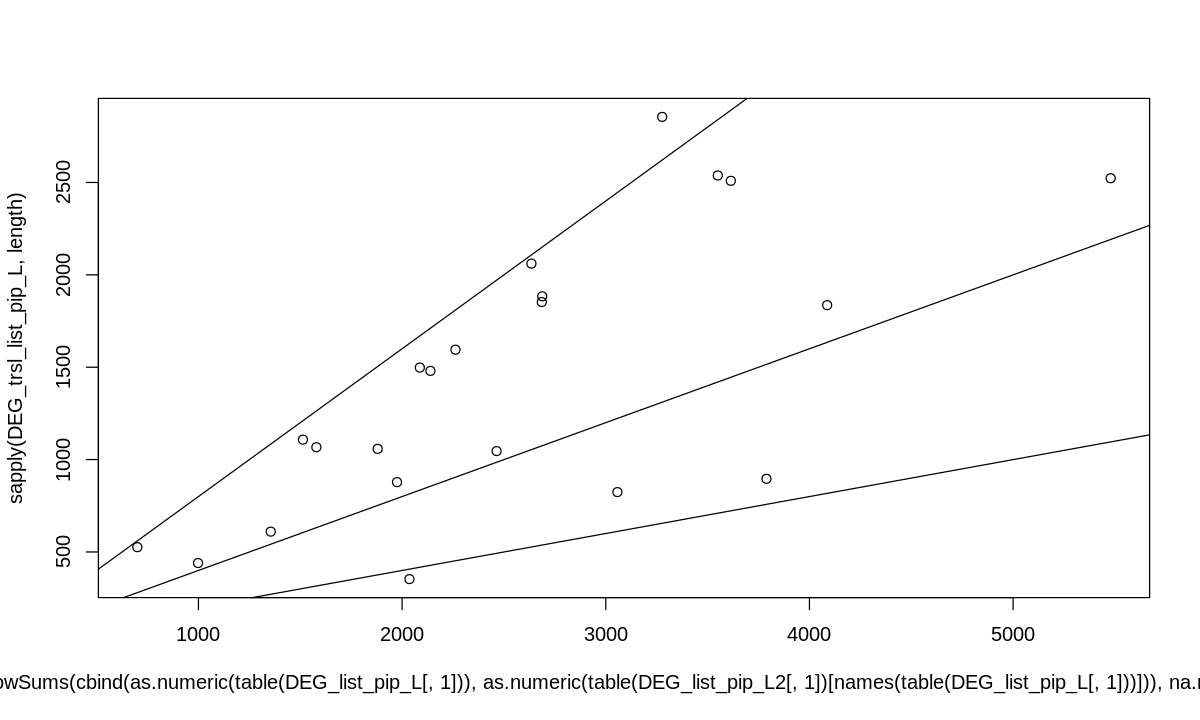

In [237]:
plot(rowSums(cbind(as.numeric(table(DEG_list_pip_L[,1])),
                  as.numeric(table(DEG_list_pip_L2[,1])[names(table(DEG_list_pip_L[,1]))])),na.rm =T),
    sapply(DEG_trsl_list_pip_L,length))
abline(a = 0, b=0.8)
abline(a = 0, b=0.4)
abline(a = 0, b=0.2)

In [195]:
str(test)

List of 46
 $ lowN_huertas2024.list       : chr [1:1745] "OG0000787" "OG0000883" "OG0000966" "OG0001048" ...
 $ remob_yang2016.list         : chr [1:1672] "OG0000508" "OG0000727" "OG0000885" "OG0000905" ...
 $ lowNP_torres2021.list       : chr [1:1133] "OG0001159" "OG0001234" "OG0001249" "OG0001260" ...
 $ remob_sekhon2019.list       : chr [1:36] "OG0002532" "OG0004387" "OG0005041" "OG0005496" ...
 $ remob_mitros2020.list       : chr [1:432] "OG0000687" "OG0001124" "OG0001131" "OG0001140" ...
 $ Andropogon_gerardii_leaf    : chr [1:353] "OG0000687" "OG0001328" "OG0001666" "OG0001727" ...
 $ Andropogon_virginicus_leaf  : chr [1:2061] "OG0000687" "OG0001051" "OG0001074" "OG0001082" ...
 $ Chrysopogon_zizanioides_leaf: chr [1:440] "OG0001159" "OG0001468" "OG0001562" "OG0001666" ...
 $ Elionorus_tripsacoides_leaf : chr [1:878] "OG0000508" "OG0000883" "OG0001060" "OG0001166" ...
 $ Miscanthus_giganteus_leaf   : chr [1:610] "OG0000687" "OG0001082" "OG0001124" "OG0001159" ...
 $ Panicum_virga

In [183]:
names(DEG_trsl_list_pip_L) = paste0(unique(DEG_list_pip_L[,1]),"_leaf")
names(DEG_trsl_list_pip_R) = paste0(unique(DEG_list_pip_R[,1]),"_root")

In [184]:
length(DEG_trsl_list)

[1] 5

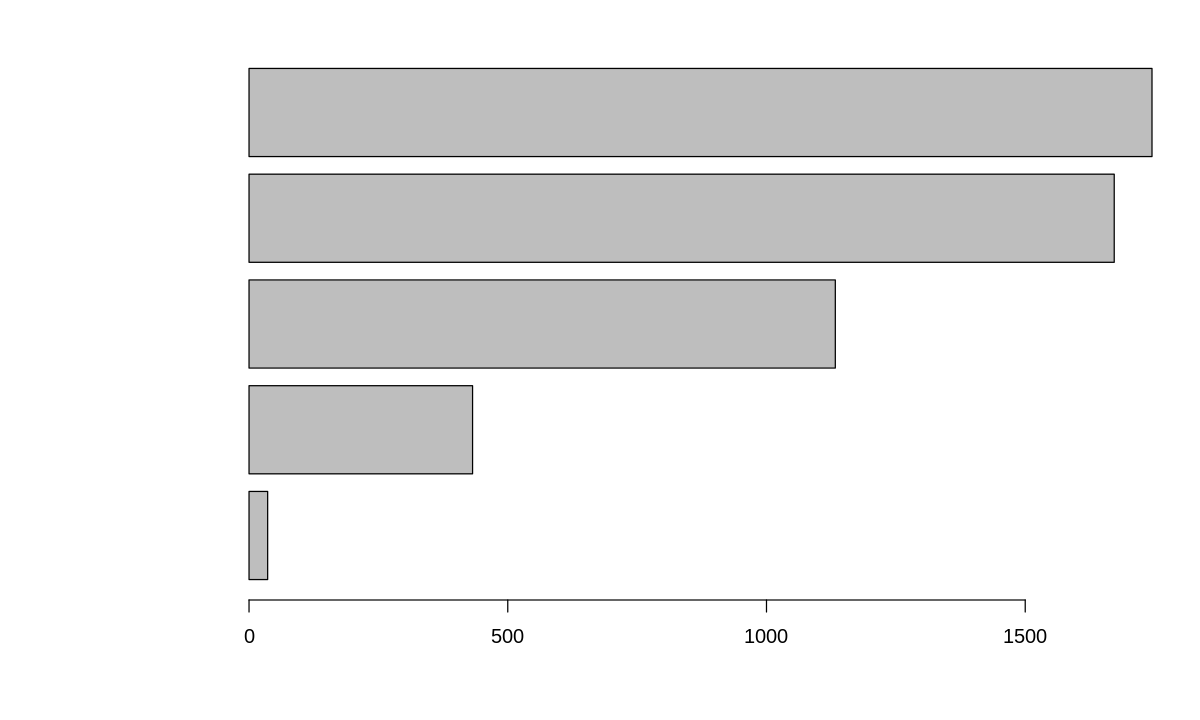

In [185]:
par(mar=c(5,10,2,2))
barplot(sort(sapply(DEG_trsl_list,length)),horiz = T,las =1)

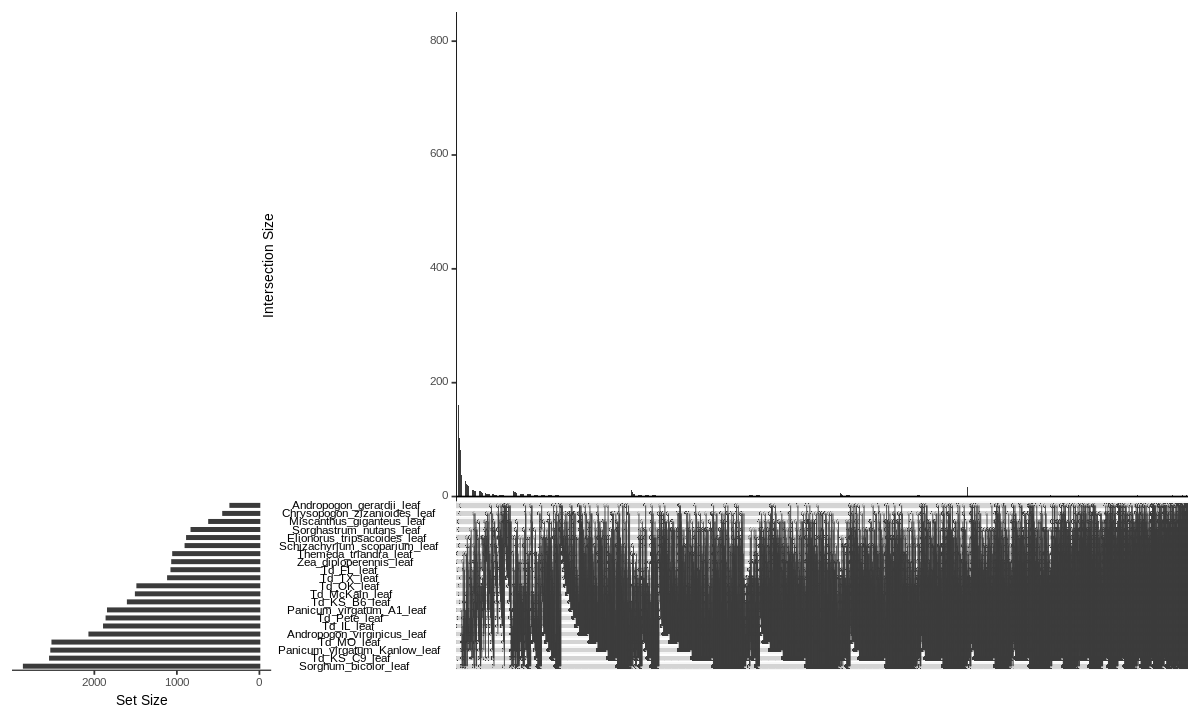

In [128]:
options(repr.plot.width=10, repr.plot.height=6)
upset(fromList(DEG_trsl_list_pip_L),nsets = 22,nintersects = NA,line.size = 0.25,
      show.numbers = F,point.size = 1)

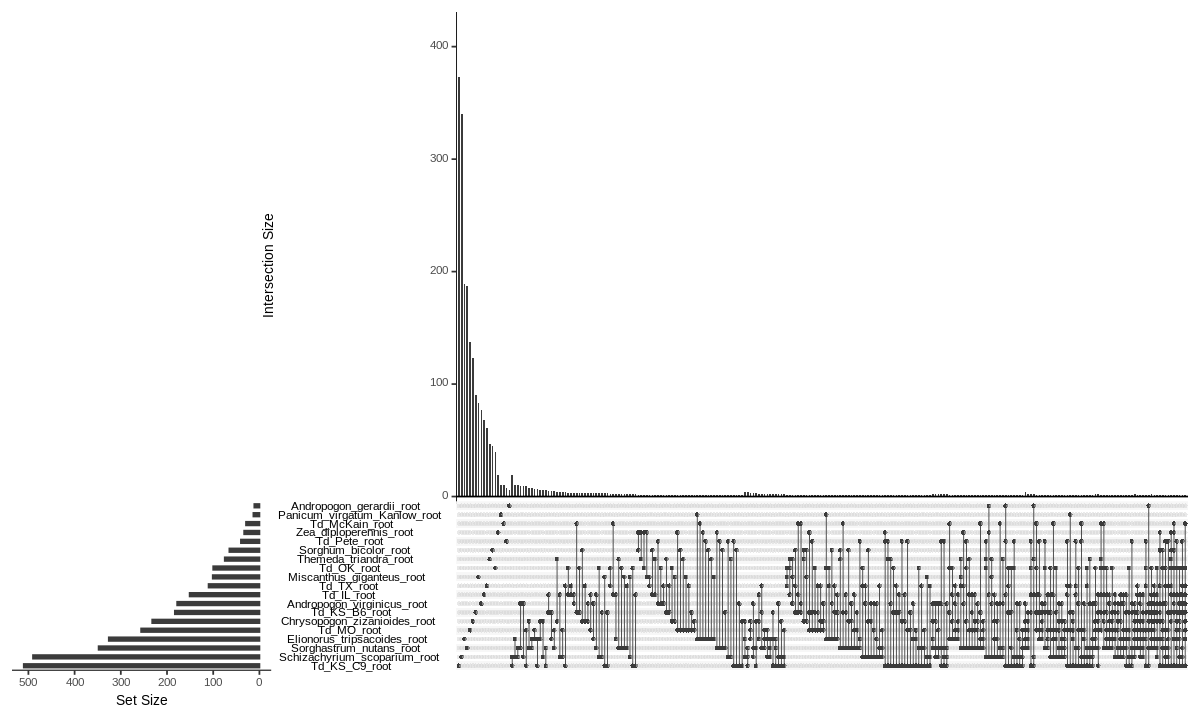

In [129]:
options(repr.plot.width=10, repr.plot.height=6)
upset(fromList(DEG_trsl_list_pip_R),nsets = 22,nintersects = NA,line.size = 0.25,
      show.numbers = F,point.size = 1)

In [196]:
set.seed(123)
rSet1 = lapply(sapply(DEG_trsl_list,length),function(x) sample(background,size = x,replace = F))
rSet2 = lapply(sapply(DEG_trsl_list_pip_L,length),function(x) sample(background,size = x,replace = F))
rSet3 = lapply(sapply(DEG_trsl_list_pip_R,length),function(x) sample(background,size = x,replace = F))
rSet4 = lapply(sapply(DEG_trsl_list_merged,length),function(x) sample(background,size = x,replace = F))

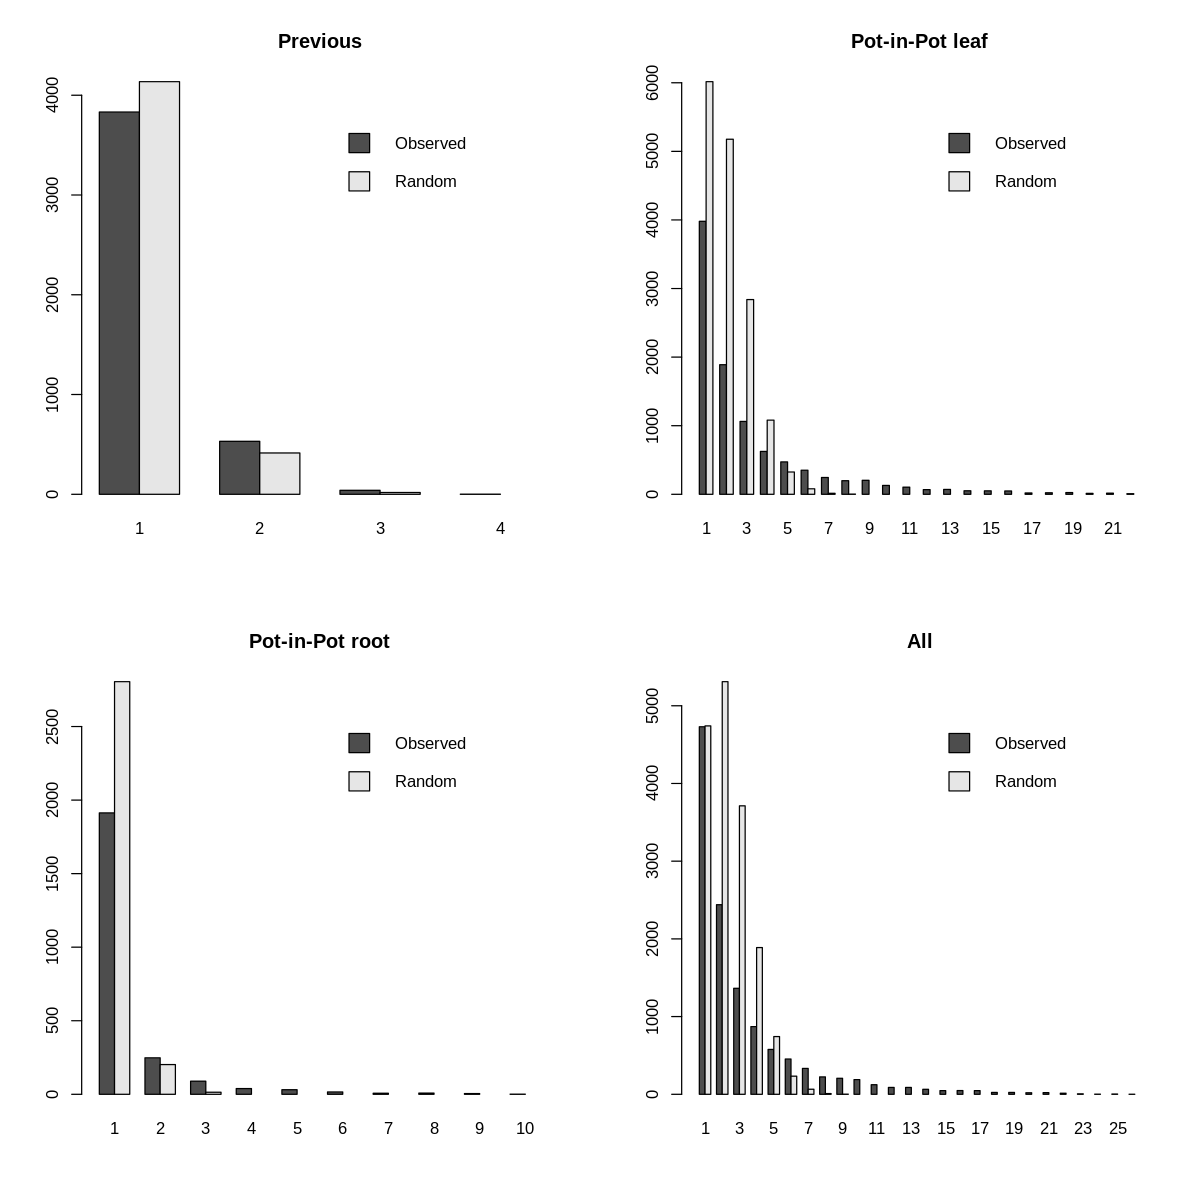

In [239]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,2))
barplot(rbind(table(table(unlist(DEG_trsl_list))),table(table(unlist(rSet1)))[names(table(table(unlist(DEG_trsl_list))))]),
        beside = T,args.legend = list(bty='n'),legend.text = c("Observed","Random"),main = "Previous")
barplot(rbind(table(table(unlist(DEG_trsl_list_pip_L))),
              table(table(unlist(rSet2)))[names(table(table(unlist(DEG_trsl_list_pip_L))))]),
        beside = T,args.legend = list(bty='n'),legend.text = c("Observed","Random"),main = "Pot-in-Pot leaf")
barplot(rbind(table(table(unlist(DEG_trsl_list_pip_R))),
              table(table(unlist(rSet3)))[names(table(table(unlist(DEG_trsl_list_pip_R))))]),
        beside = T,args.legend = list(bty='n'),legend.text = c("Observed","Random"),main = "Pot-in-Pot root")
barplot(rbind(table(table(unlist(DEG_trsl_list_merged))),
              table(table(unlist(rSet4)))[names(table(table(unlist(DEG_trsl_list_merged))))]),
        beside = T,args.legend = list(bty='n'),legend.text = c("Observed","Random"),main = "All")

In [198]:
GOI = names(table(unlist(DEG_trsl_list)))[which(table(unlist(DEG_trsl_list))>1)]
pip_L_GOI = names(table(unlist(DEG_trsl_list_pip_L)))[which(table(unlist(DEG_trsl_list_pip_L))>4)]
pip_R_GOI = names(table(unlist(DEG_trsl_list_pip_R)))[which(table(unlist(DEG_trsl_list_pip_R))>1)]
mergedGOI = names(table(unlist(DEG_trsl_list_merged)))[which(table(unlist(DEG_trsl_list_merged))>5)]

In [199]:
length(GOI)
length(pip_L_GOI)
length(pip_R_GOI)
length(mergedGOI)

[1] 572

[1] 2095

[1] 444

[1] 2026

In [41]:
source("/workdir/sh2246/p_geneModelEvaluation/src/S00_basicFunction.R")

In [439]:
RAO = read.table("/workdir/sh2246/p_phyloGWAS/output/Yeaman2024RAO_OGID.txt")

In [200]:
testRes_envPC1_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_v2.txt",header =T)
testRes_envPC2_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_v2.txt",header =T)

In [248]:
testRes_lifeHistory = read.table("/workdir/sh2246/p_phyloGWAS/output/fullVsReduced_lifeHistory_241112.txt",header = T)
testRes_rhizome = read.table("/workdir/sh2246/p_phyloGWAS/output/fullVsReduced_rhizomes_241123.txt",header = T)

In [201]:
envPC1_candidate = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=400]
envPC2_candidate = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=20]
background = union(testRes_envPC1_v2$OG,testRes_envPC2_v2$OG)

In [259]:
background = testRes_lifeHistory$OG

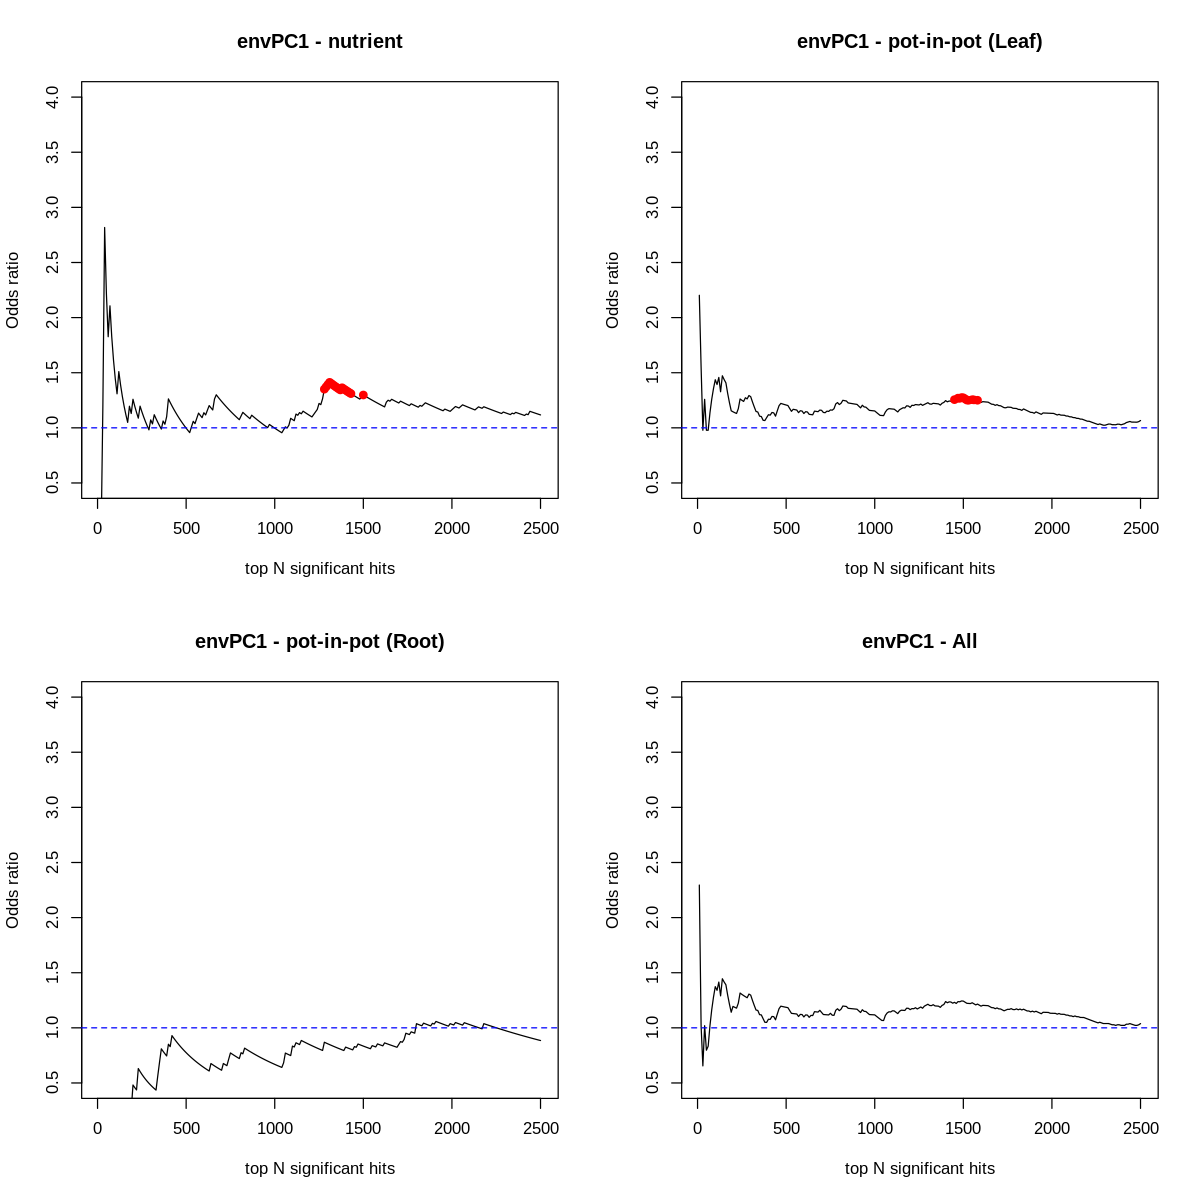

In [202]:
# sequential Fisher's exact test
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow= c(2,2))
OR_envPC1 = c()
p_envPC1 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,GOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC1,type = 'l',ylim = c(0.5,4),
     main = 'envPC1 - nutrient',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC1,col = ifelse(p_envPC1< .05&OR_envPC1>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

OR_envPC1 = c()
p_envPC1 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_L_GOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC1,type = 'l',ylim = c(0.5,4),
     main = 'envPC1 - pot-in-pot (Leaf)',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC1,col = ifelse(p_envPC1< .05&OR_envPC1>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

OR_envPC1 = c()
p_envPC1 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_R_GOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC1,type = 'l',ylim = c(0.5,4),
     main = 'envPC1 - pot-in-pot (Root)',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC1,col = ifelse(p_envPC1< .05&OR_envPC1>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

OR_envPC1 = c()
p_envPC1 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,mergedGOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC1,type = 'l',ylim = c(0.5,4),
     main = 'envPC1 - All',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC1,col = ifelse(p_envPC1< .05&OR_envPC1>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

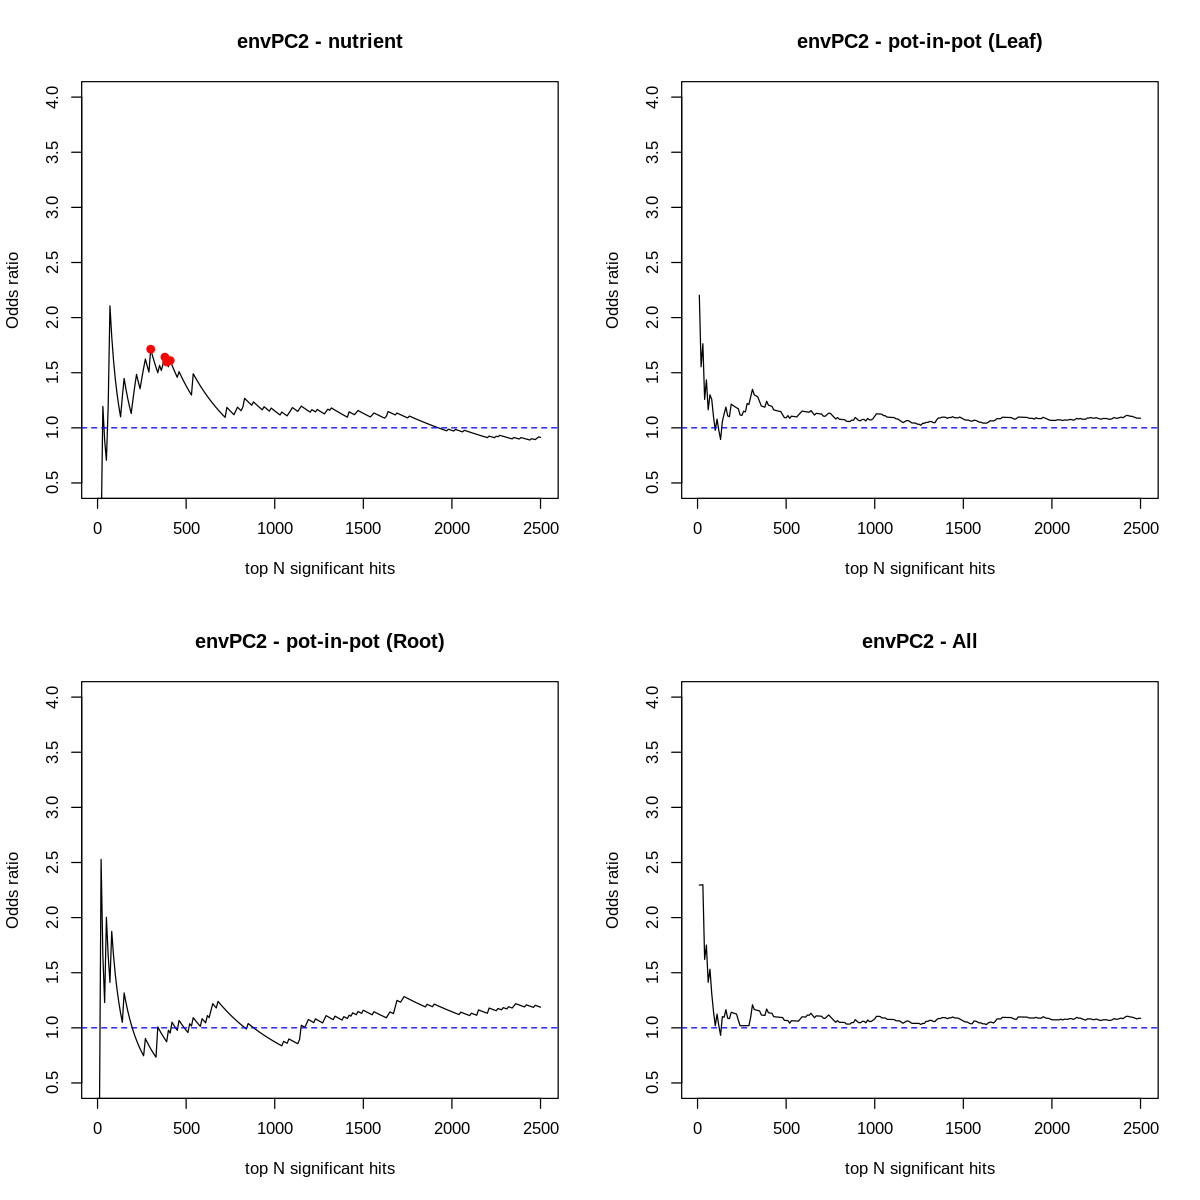

In [203]:
# sequential Fisher's exact test
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow= c(2,2))
OR_envPC2 = c()
p_envPC2 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,GOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC2,type = 'l',ylim = c(0.5,4),
     main = 'envPC2 - nutrient',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC2,col = ifelse(p_envPC2< .05&OR_envPC2>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

OR_envPC2 = c()
p_envPC2 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_L_GOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC2,type = 'l',ylim = c(0.5,4),
     main = 'envPC2 - pot-in-pot (Leaf)',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC2,col = ifelse(p_envPC2< .05&OR_envPC2>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

OR_envPC2 = c()
p_envPC2 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_R_GOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC2,type = 'l',ylim = c(0.5,4),
     main = 'envPC2 - pot-in-pot (Root)',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC2,col = ifelse(p_envPC2< .05&OR_envPC2>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

OR_envPC2 = c()
p_envPC2 = c()
for (i in seq(10,2500,10)){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,mergedGOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
plot(seq(10,2500,10),OR_envPC2,type = 'l',ylim = c(0.5,4),
     main = 'envPC2 - All',xlab = "top N significant hits",ylab = "Odds ratio")
points(seq(10,2500,10),OR_envPC2,col = ifelse(p_envPC2< .05&OR_envPC2>1.25,"red",NA), pch = 19)
abline(h=1,col = "blue",lty = 2)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”


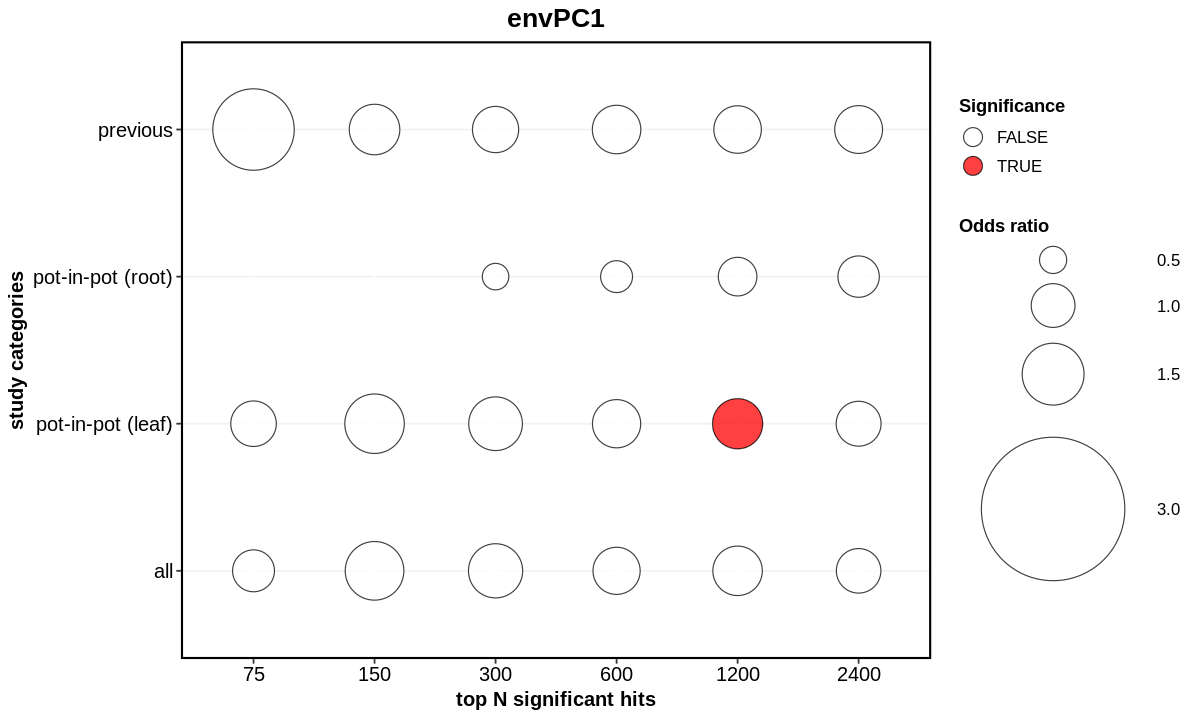

In [204]:
# bubble plots
options(repr.plot.width=10, repr.plot.height=6)
N = c(75,150,300,600,1200,2400)
OR_envPC1 = c()
p_envPC1 = c()
for (i in N){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,GOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
for (i in N){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_L_GOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
for (i in N){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_R_GOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
for (i in N){
    tmp = testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,mergedGOI),alternative = "greater")
    OR_envPC1 = c(OR_envPC1,tmpRes$estimate)
    p_envPC1 = c(p_envPC1,tmpRes$p)
}
enrichmentRes_envPC1 = data.frame(N = N, OR = OR_envPC1,p = p_envPC1,sig = as.character(p_envPC1 < 0.05),
                                  study = rep(c("previous","pot-in-pot (leaf)",
                                                "pot-in-pot (root)","all"),each = length(N)))

ggplot(enrichmentRes_envPC1, aes(x = as.factor(N), y = study),title = "envPC1") + 
    geom_point(aes(size = OR, fill = sig), alpha = 0.75, shape = 21) + 
    scale_size_continuous(limits = c(0.01, 3), range = c(.01,40), breaks = c(0.5,1,1.5,3),transform = 'exp') + 
    labs(title = 'envPC1', x= "top N significant hits", y = "study categories", 
         size = "Odds ratio", fill = "Significance")  + 
    theme(legend.key=element_blank(), 
          plot.title = element_text(colour = "black", size = 16,face = 'bold',hjust = .5),
          axis.title.x = element_text(colour = "black", size = 12,face = 'bold', angle = 0), 
          axis.title.y = element_text(colour = "black", size = 12,face = 'bold'), 
          axis.text.x = element_text(colour = "black", size = 12, angle = 0), 
          axis.text.y = element_text(colour = "black", size = 12), 
          legend.text = element_text(size = 10, colour ="black"), 
          legend.title = element_text(size = 11, face = "bold"), panel.background = element_blank(), 
          panel.border = element_rect(colour = "black", fill = NA, size = 1.2), 
          legend.position = "right", panel.grid.major.y = element_line(colour = "grey95")) +  
    scale_fill_manual(values = c("white","red"), guide = guide_legend(override.aes = list(size=5))) + 
    scale_y_discrete(limits = rev(levels(enrichmentRes_envPC1$stress))) 


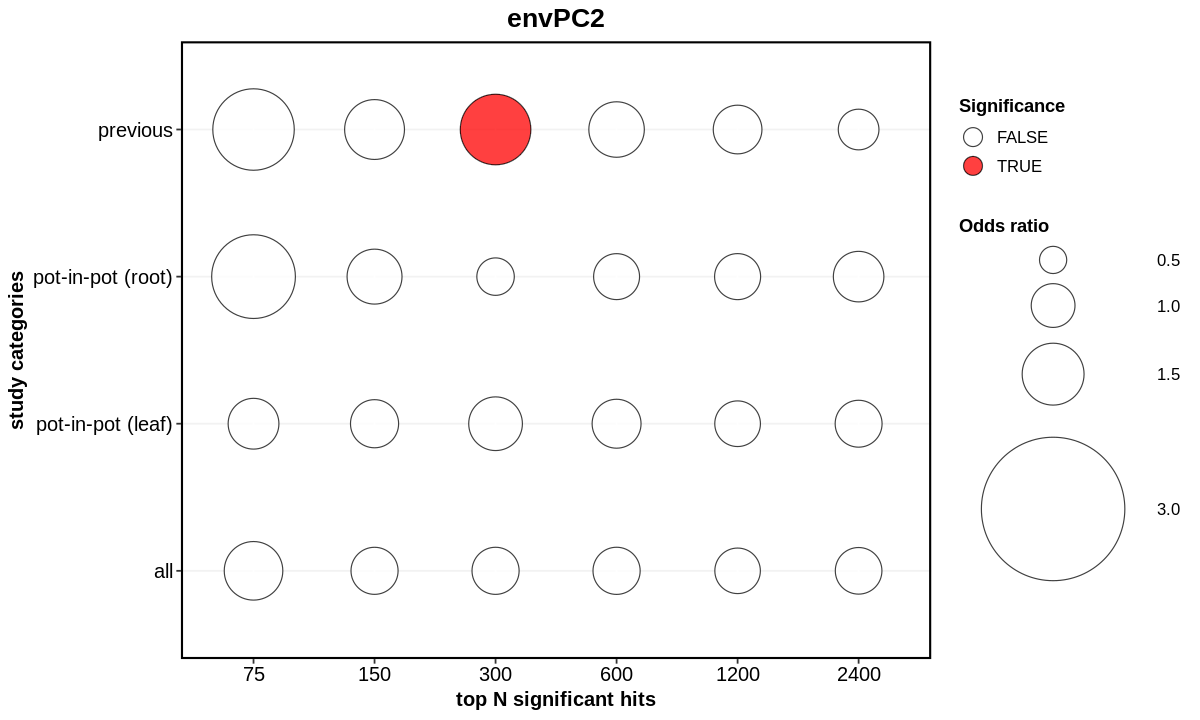

In [205]:
# bubble plots
N = c(75,150,300,600,1200,2400)
OR_envPC2 = c()
p_envPC2 = c()
for (i in N){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,GOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
for (i in N){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_L_GOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
for (i in N){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_R_GOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
for (i in N){
    tmp = testRes_envPC2_v2$OG[rank(testRes_envPC2_v2$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,mergedGOI),alternative = "greater")
    OR_envPC2 = c(OR_envPC2,tmpRes$estimate)
    p_envPC2 = c(p_envPC2,tmpRes$p)
}
enrichmentRes_envPC2 = data.frame(N = N, OR = OR_envPC2,p = p_envPC2,sig = as.character(p_envPC2 < 0.05),
                                  study = rep(c("previous","pot-in-pot (leaf)",
                                                "pot-in-pot (root)","all"),each = length(N)))

ggplot(enrichmentRes_envPC2, aes(x = as.factor(N), y = study),title = "envPC2") + 
    geom_point(aes(size = OR, fill = sig), alpha = 0.75, shape = 21) + 
    scale_size_continuous(limits = c(0.01, 3), range = c(.01,40), breaks = c(0.5,1,1.5,3),transform = 'exp') + 
    labs(title = 'envPC2', x= "top N significant hits", y = "study categories", 
         size = "Odds ratio", fill = "Significance")  + 
    theme(legend.key=element_blank(), 
          plot.title = element_text(colour = "black", size = 16,face = 'bold',hjust = .5),
          axis.title.x = element_text(colour = "black", size = 12,face = 'bold', angle = 0), 
          axis.title.y = element_text(colour = "black", size = 12,face = 'bold'), 
          axis.text.x = element_text(colour = "black", size = 12, angle = 0), 
          axis.text.y = element_text(colour = "black", size = 12), 
          legend.text = element_text(size = 10, colour ="black"), 
          legend.title = element_text(size = 11, face = "bold"), panel.background = element_blank(), 
          panel.border = element_rect(colour = "black", fill = NA, size = 1.2), 
          legend.position = "right", panel.grid.major.y = element_line(colour = "grey95")) +  
    scale_fill_manual(values = c("white","red"), guide = guide_legend(override.aes = list(size=5))) + 
    scale_y_discrete(limits = rev(levels(enrichmentRes_envPC2$stress))) 


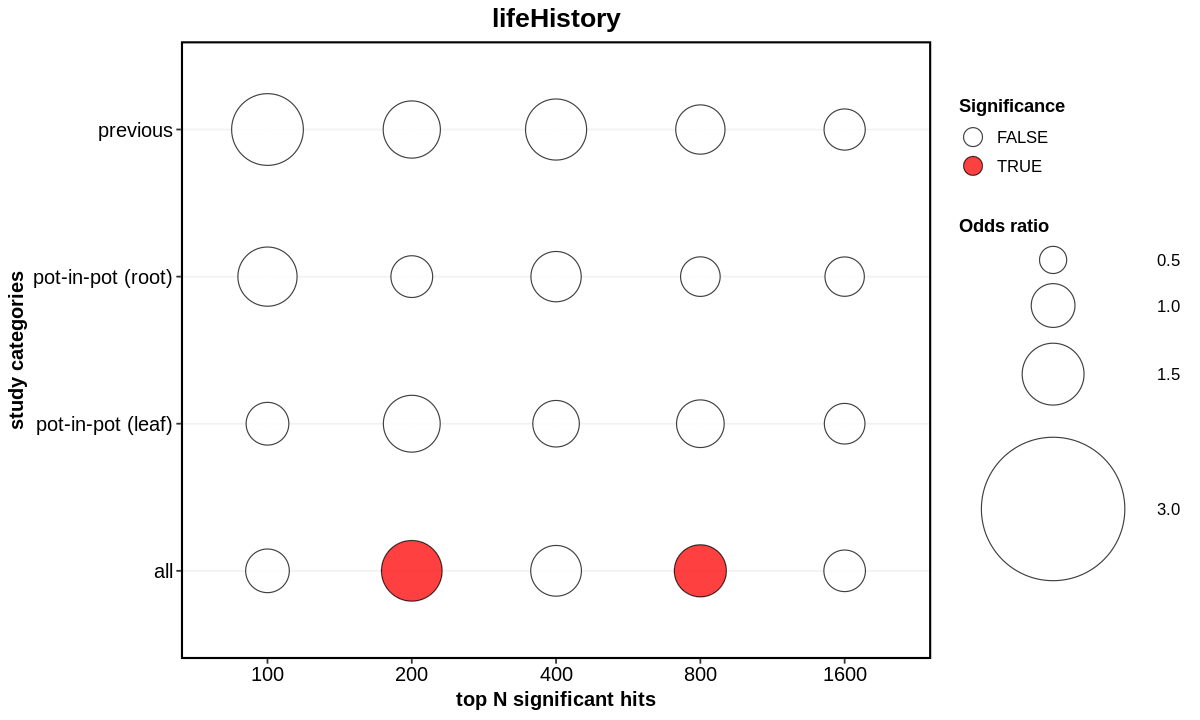

In [263]:
# bubble plots
options(repr.plot.width=10, repr.plot.height=6)
N = c(100,200,400,800,1600)
OR_lifeHistory = c()
p_lifeHistory = c()
for (i in N){
    tmp = testRes_lifeHistory$OG[rank(testRes_lifeHistory$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,GOI),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}
for (i in N){
    tmp = testRes_lifeHistory$OG[rank(testRes_lifeHistory$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_L_GOI),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}
for (i in N){
    tmp = testRes_lifeHistory$OG[rank(testRes_lifeHistory$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_R_GOI),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}
for (i in N){
    tmp = testRes_lifeHistory$OG[rank(testRes_lifeHistory$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,mergedGOI),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}
enrichmentRes_lifeHistory = data.frame(N = N, OR = OR_lifeHistory,p = p_lifeHistory,sig = as.character(p_lifeHistory < 0.05),
                                  study = rep(c("previous","pot-in-pot (leaf)",
                                                "pot-in-pot (root)","all"),each = length(N)))

ggplot(enrichmentRes_lifeHistory, aes(x = as.factor(N), y = study),title = "lifeHistory") + 
    geom_point(aes(size = OR, fill = sig), alpha = 0.75, shape = 21) + 
    scale_size_continuous(limits = c(0.01, 3), range = c(.01,40), breaks = c(0.5,1,1.5,3),transform = 'exp') + 
    labs(title = 'lifeHistory', x= "top N significant hits", y = "study categories", 
         size = "Odds ratio", fill = "Significance")  + 
    theme(legend.key=element_blank(), 
          plot.title = element_text(colour = "black", size = 16,face = 'bold',hjust = .5),
          axis.title.x = element_text(colour = "black", size = 12,face = 'bold', angle = 0), 
          axis.title.y = element_text(colour = "black", size = 12,face = 'bold'), 
          axis.text.x = element_text(colour = "black", size = 12, angle = 0), 
          axis.text.y = element_text(colour = "black", size = 12), 
          legend.text = element_text(size = 10, colour ="black"), 
          legend.title = element_text(size = 11, face = "bold"), panel.background = element_blank(), 
          panel.border = element_rect(colour = "black", fill = NA, size = 1.2), 
          legend.position = "right", panel.grid.major.y = element_line(colour = "grey95")) +  
    scale_fill_manual(values = c("white","red"), guide = guide_legend(override.aes = list(size=5))) + 
    scale_y_discrete(limits = rev(levels(enrichmentRes_lifeHistory$stress))) 


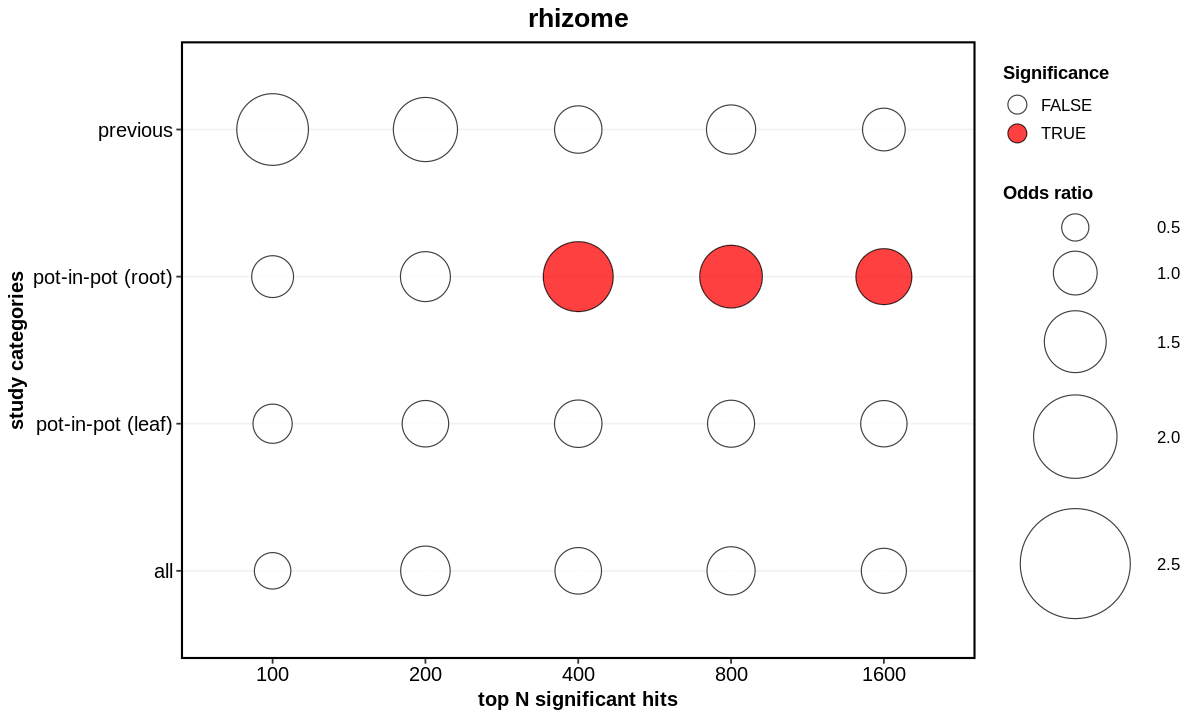

In [268]:
# bubble plots
N = c(100,200,400,800,1600)
OR_rhizome = c()
p_rhizome = c()
for (i in N){
    tmp = testRes_rhizome$OG[rank(testRes_rhizome$partialP_ESM2)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,GOI),alternative = "greater")
    OR_rhizome = c(OR_rhizome,tmpRes$estimate)
    p_rhizome = c(p_rhizome,tmpRes$p)
}
for (i in N){
    tmp = testRes_rhizome$OG[rank(testRes_rhizome$partialP_ESM2)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_L_GOI),alternative = "greater")
    OR_rhizome = c(OR_rhizome,tmpRes$estimate)
    p_rhizome = c(p_rhizome,tmpRes$p)
}
for (i in N){
    tmp = testRes_rhizome$OG[rank(testRes_rhizome$partialP_ESM2)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,pip_R_GOI),alternative = "greater")
    OR_rhizome = c(OR_rhizome,tmpRes$estimate)
    p_rhizome = c(p_rhizome,tmpRes$p)
}
for (i in N){
    tmp = testRes_rhizome$OG[rank(testRes_rhizome$partialP_ESM2)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,mergedGOI),alternative = "greater")
    OR_rhizome = c(OR_rhizome,tmpRes$estimate)
    p_rhizome = c(p_rhizome,tmpRes$p)
}
enrichmentRes_rhizome = data.frame(N = N, OR = OR_rhizome,p = p_rhizome,sig = as.character(p_rhizome < 0.05),
                                  study = rep(c("previous","pot-in-pot (leaf)",
                                                "pot-in-pot (root)","all"),each = length(N)))

ggplot(enrichmentRes_rhizome, aes(x = as.factor(N), y = study),title = "rhizome") + 
    geom_point(aes(size = OR, fill = sig), alpha = 0.75, shape = 21) + 
    scale_size_continuous(limits = c(0.01, 3), range = c(.01,40), breaks = c(0.5,1,1.5,2,2.5),transform = 'exp') + 
    labs(title = 'rhizome', x= "top N significant hits", y = "study categories", 
         size = "Odds ratio", fill = "Significance")  + 
    theme(legend.key=element_blank(), 
          plot.title = element_text(colour = "black", size = 16,face = 'bold',hjust = .5),
          axis.title.x = element_text(colour = "black", size = 12,face = 'bold', angle = 0), 
          axis.title.y = element_text(colour = "black", size = 12,face = 'bold'), 
          axis.text.x = element_text(colour = "black", size = 12, angle = 0), 
          axis.text.y = element_text(colour = "black", size = 12), 
          legend.text = element_text(size = 10, colour ="black"), 
          legend.title = element_text(size = 11, face = "bold"), panel.background = element_blank(), 
          panel.border = element_rect(colour = "black", fill = NA, size = 1.2), 
          legend.position = "right", panel.grid.major.y = element_line(colour = "grey95")) +  
    scale_fill_manual(values = c("white","red"), guide = guide_legend(override.aes = list(size=5))) + 
    scale_y_discrete(limits = rev(levels(enrichmentRes_rhizome$stress))) 


In [269]:
cont_table(testRes_rhizome$OG[rank(testRes_rhizome$partialP_ESM2)<=400],background,pip_R_GOI)
fisher.test(cont_table(testRes_rhizome$OG[rank(testRes_rhizome$partialP_ESM2)<=400],background,pip_R_GOI),
            alternative = "greater")

14,386
292,13682



	Fisher's Exact Test for Count Data

data:  cont_table(testRes_rhizome$OG[rank(testRes_rhizome$partialP_ESM2) <= 400], background, pip_R_GOI)
p-value = 0.04765
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 1.00753     Inf
sample estimates:
odds ratio 
  1.699361 


In [114]:
enrichmentRes_envPC2

N,OR,p,sig,study
<dbl>,<dbl>,<dbl>,<chr>,<chr>
25,0.0000000,1.00000000,FALSE,previous
50,0.7060242,0.75963321,FALSE,previous
100,1.4458928,0.30891362,FALSE,previous
200,1.2591276,0.33079851,FALSE,previous
400,1.5544992,0.05999095,FALSE,previous
800,1.1714249,0.24729129,FALSE,previous
1600,1.1033349,0.28062862,FALSE,previous
25,1.1270071,0.54342377,FALSE,pot-in-pot (leaf)
50,0.8267538,0.70490603,FALSE,pot-in-pot (leaf)


In [721]:
fisher.test(cont_table(envPC2_candidate,background,coldResponsiveGenes),alternative = "greater")
fisher.test(cont_table(envPC2_candidate,background,heatResponsiveGenes),alternative = "greater")
fisher.test(cont_table(envPC2_candidate,background,waterResponsiveGenes),alternative = "greater")
fisher.test(cont_table(envPC2_candidate,background,droughtResponsiveGenes),alternative = "greater")
fisher.test(cont_table(envPC2_candidate,background,unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))])),alternative = "greater")
fisher.test(cont_table(envPC2_candidate,background,RAO[,2]),alternative = "greater")


	Fisher's Exact Test for Count Data

data:  cont_table(envPC2_candidate, background, coldResponsiveGenes)
p-value = 0.3688
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.3635191       Inf
sample estimates:
odds ratio 
  1.458272 



	Fisher's Exact Test for Count Data

data:  cont_table(envPC2_candidate, background, heatResponsiveGenes)
p-value = 0.05252
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.9864068       Inf
sample estimates:
odds ratio 
  2.608585 



	Fisher's Exact Test for Count Data

data:  cont_table(envPC2_candidate, background, waterResponsiveGenes)
p-value = 0.007777
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 1.532359      Inf
sample estimates:
odds ratio 
  3.832058 



	Fisher's Exact Test for Count Data

data:  cont_table(envPC2_candidate, background, droughtResponsiveGenes)
p-value = 0.1307
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.6485946       Inf
sample estimates:
odds ratio 
  2.603108 



	Fisher's Exact Test for Count Data

data:  cont_table(envPC2_candidate, background, unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))]))
p-value = 0.04089
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 1.06278     Inf
sample estimates:
odds ratio 
  3.052431 



	Fisher's Exact Test for Count Data

data:  cont_table(envPC2_candidate, background, RAO[, 2])
p-value = 1
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
   0 Inf
sample estimates:
odds ratio 
         0 


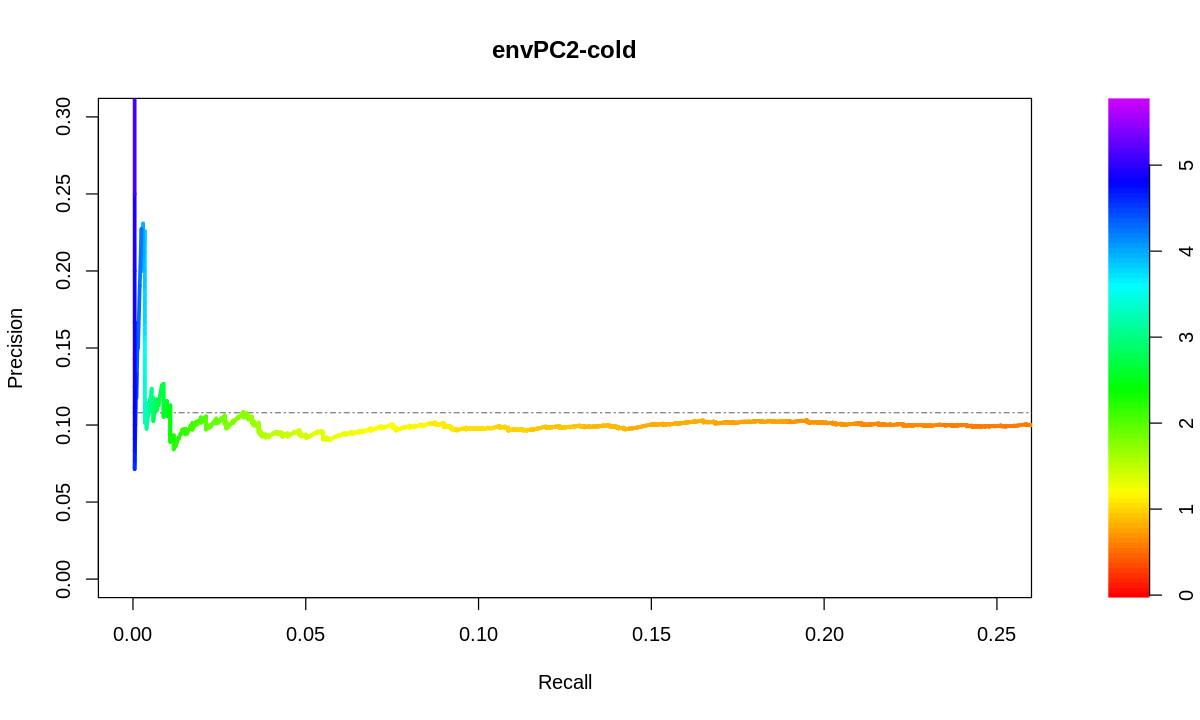

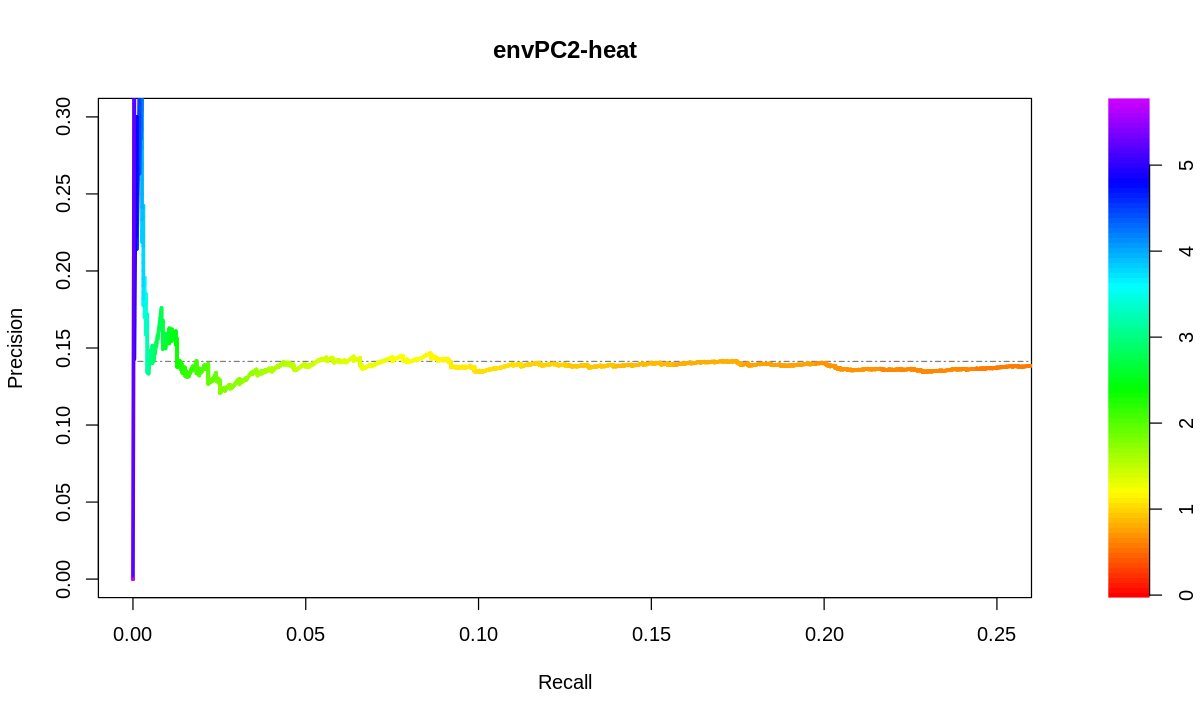

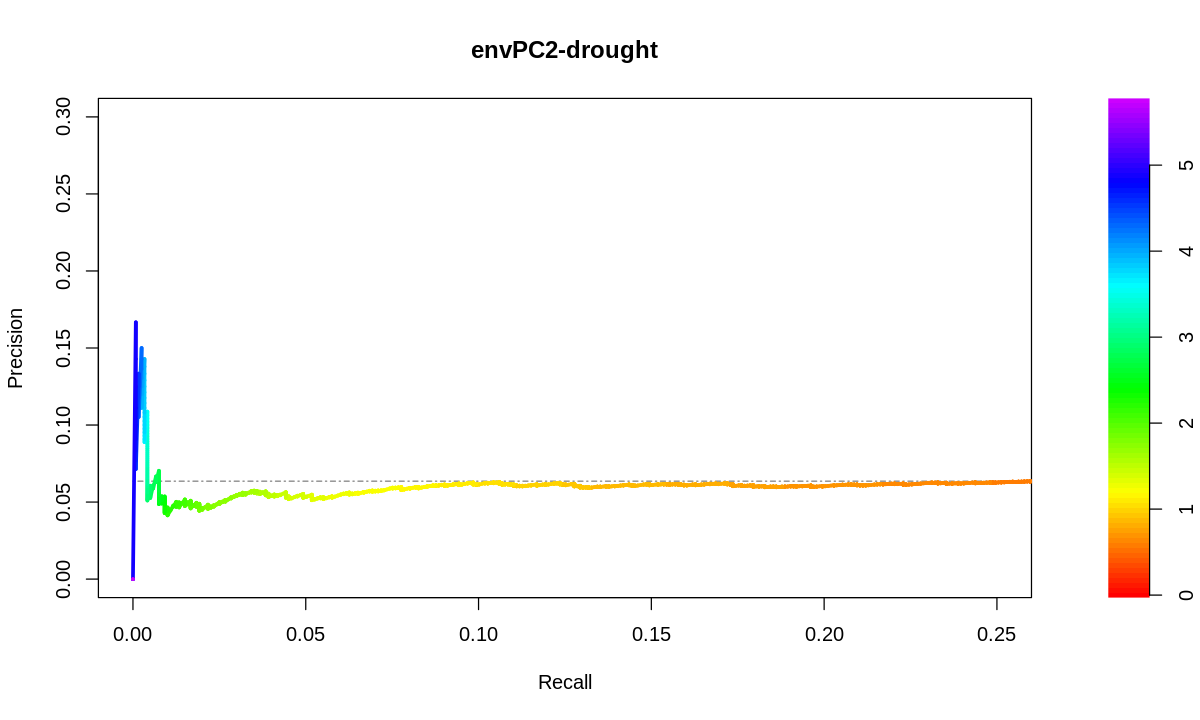

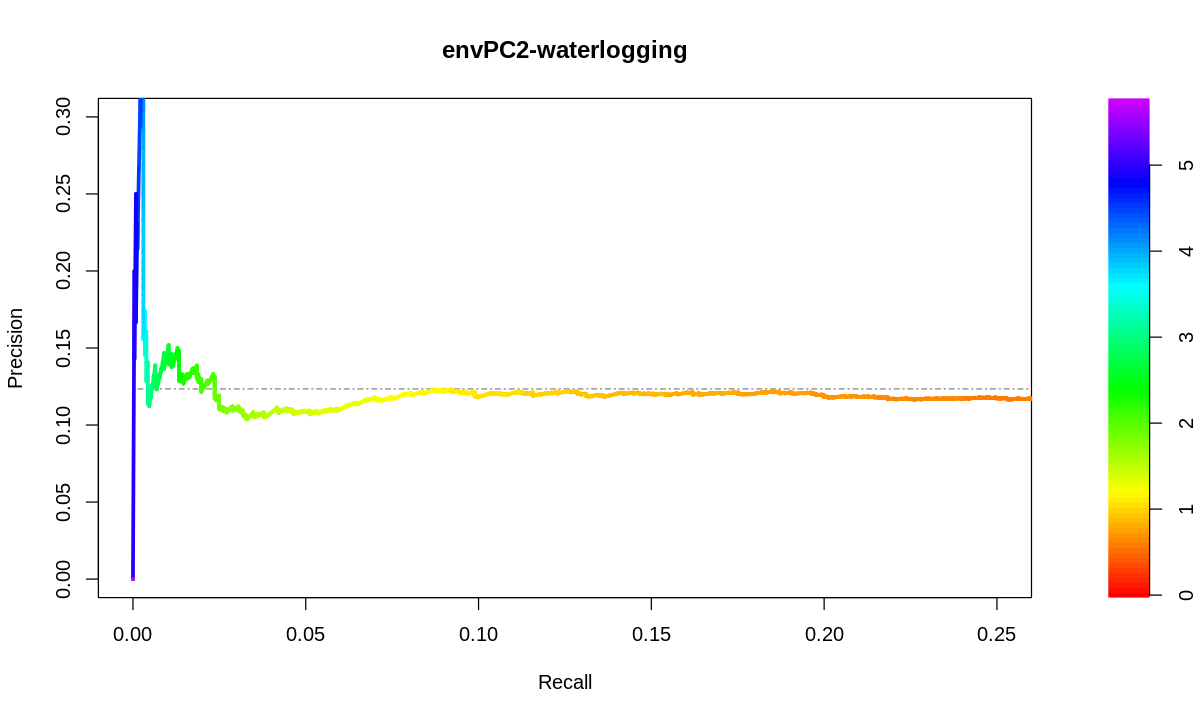

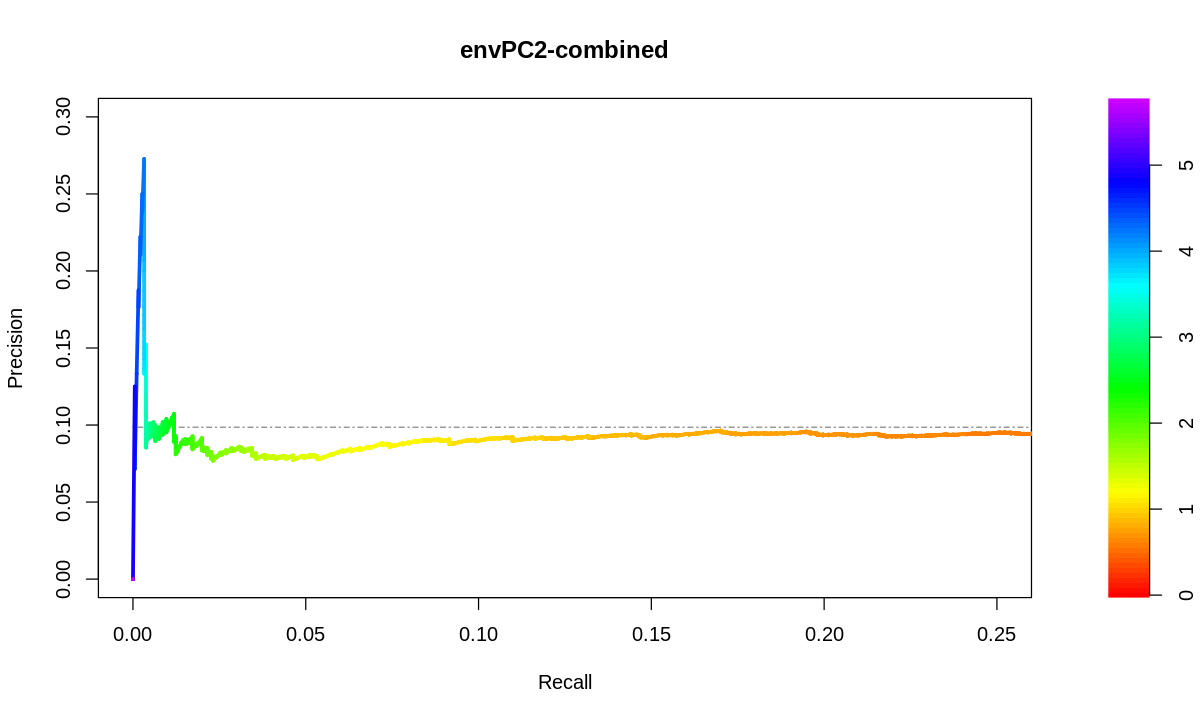

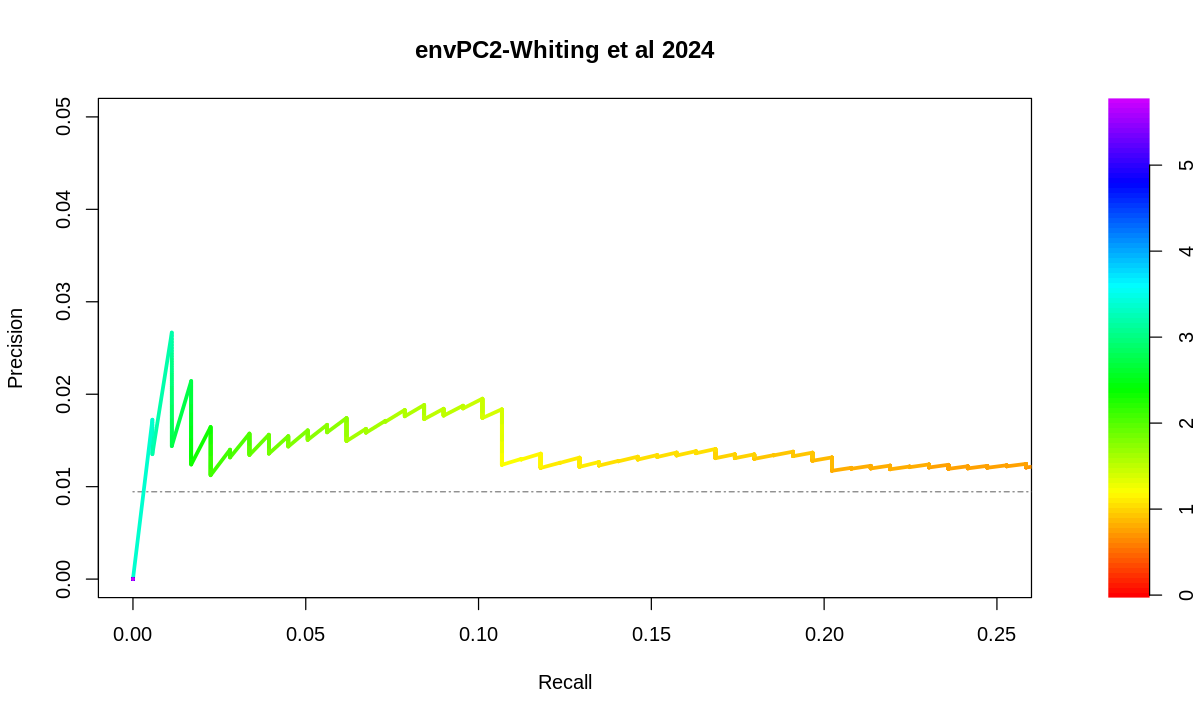

In [722]:
options(repr.plot.width=10, repr.plot.height=6)
#cold
fg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[testRes_envPC2_v2$OG%in%coldResponsiveGenes]
bg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[!testRes_envPC2_v2$OG%in%coldResponsiveGenes]
pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
plot(pr_RAO,rand.plot = T,ylim = c(0,0.3),xlim = c(0,.25),auc.main =F,main = "envPC2-cold")
#heat
fg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[testRes_envPC2_v2$OG%in%heatResponsiveGenes]
bg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[!testRes_envPC2_v2$OG%in%heatResponsiveGenes]
pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
plot(pr_RAO,rand.plot = T,ylim = c(0,0.3),xlim = c(0,.25),auc.main =F,main = "envPC2-heat")
#drought
fg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[testRes_envPC2_v2$OG%in%droughtResponsiveGenes]
bg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[!testRes_envPC2_v2$OG%in%droughtResponsiveGenes]
pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
plot(pr_RAO,rand.plot = T,ylim = c(0,0.3),xlim = c(0,.25),auc.main =F,main = "envPC2-drought")
#waterlogging
fg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[testRes_envPC2_v2$OG%in%waterResponsiveGenes]
bg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[!testRes_envPC2_v2$OG%in%waterResponsiveGenes]
pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
plot(pr_RAO,rand.plot = T,ylim = c(0,0.3),xlim = c(0,.25),auc.main =F,main = "envPC2-waterlogging")
#combined
fg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[testRes_envPC2_v2$OG%in%unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))])]
bg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[!testRes_envPC2_v2$OG%in%unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))])]
pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
plot(pr_RAO,rand.plot = T,ylim = c(0,0.3),xlim = c(0,.25),auc.main =F,main = "envPC2-combined")
#RAO (Yeaman)
fg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[testRes_envPC2_v2$OG%in%RAO[,2]]
bg_RAO = -log10(as.numeric(testRes_envPC2_v2$p))[!testRes_envPC2_v2$OG%in%RAO[,2]]
pr_RAO = pr.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
roc_RAO = roc.curve(scores.class0 = fg_RAO, scores.class1 = bg_RAO[bg_RAO!=Inf], curve = T,rand.compute = T)
plot(pr_RAO,rand.plot = T,ylim = c(0,0.05),xlim = c(0,.25),auc.main =F,main = "envPC2-Whiting et al 2024")

In [461]:
2000*.02

[1] 40

In [723]:
cont_table(envPC2_candidate,background,unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))]))
cont_table(envPC2_candidate,background,unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))]))/rowSums(cont_table(envPC2_candidate,background,unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))])))

5,15
1853,16971


0.25000000,0.7500000
0.09843816,0.9015618


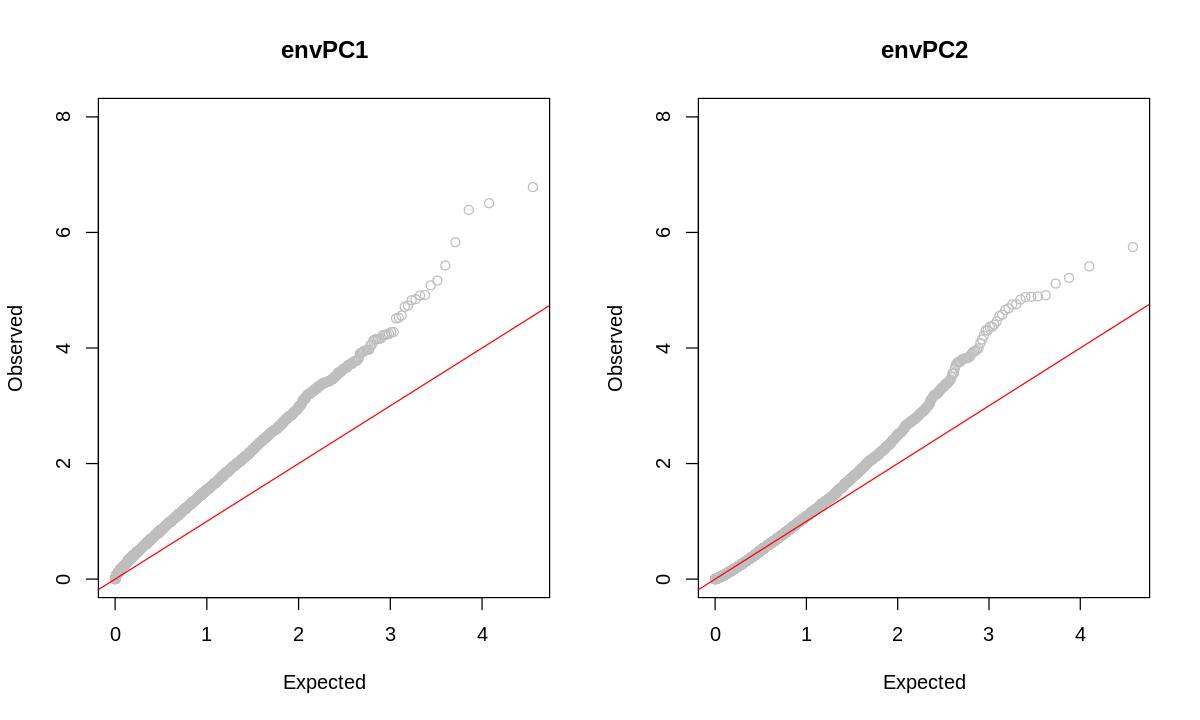

In [808]:
options(repr.plot.width=10, repr.plot.height=6)
par(mfrow = c(1,2))
exptd = -log10(ppoints(nrow(testRes_envPC1_v2)))
plot(exptd,sort(testRes_envPC1_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC1",ylim = c(0,8))
abline(a = 0, b=1,col = "red")

exptd = -log10(ppoints(nrow(testRes_envPC2_v2)))
plot(exptd,sort(testRes_envPC2_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC2",ylim = c(0,8))
abline(a = 0, b=1,col = "red")


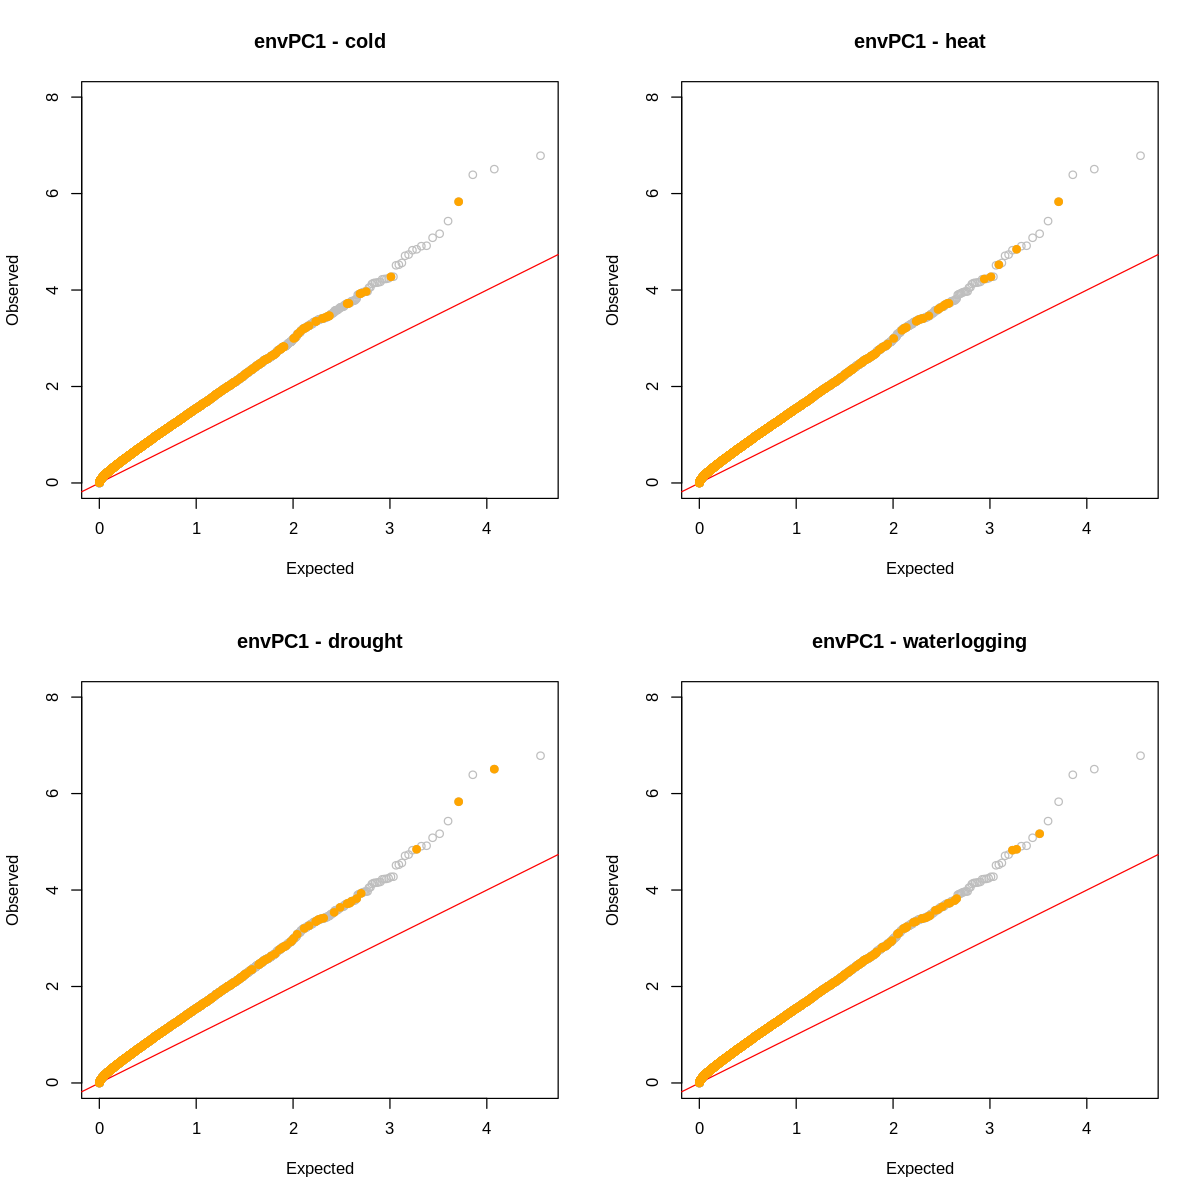

In [724]:
options(repr.plot.width=10, repr.plot.height=10)
exptd = -log10(ppoints(nrow(testRes_envPC1_v2)))
par(mfrow = c(2,2))
plot(exptd,sort(testRes_envPC1_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC1 - cold (2,212)",ylim = c(0,8))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%coldResponsiveGenes],
       sort(testRes_envPC1_v2$logp[testRes_envPC1_v2$OG%in%coldResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)
plot(exptd,sort(testRes_envPC1_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC1 - heat (2,874)",ylim = c(0,8))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%heatResponsiveGenes],
       sort(testRes_envPC1_v2$logp[testRes_envPC1_v2$OG%in%heatResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)
plot(exptd,sort(testRes_envPC1_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC1 - drought (1,292)",ylim = c(0,8))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%droughtResponsiveGenes],
       sort(testRes_envPC1_v2$logp[testRes_envPC1_v2$OG%in%droughtResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)
plot(exptd,sort(testRes_envPC1_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC1 - waterlogging (2,524)",ylim = c(0,8))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%waterResponsiveGenes],
       sort(testRes_envPC1_v2$logp[testRes_envPC1_v2$OG%in%waterResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)

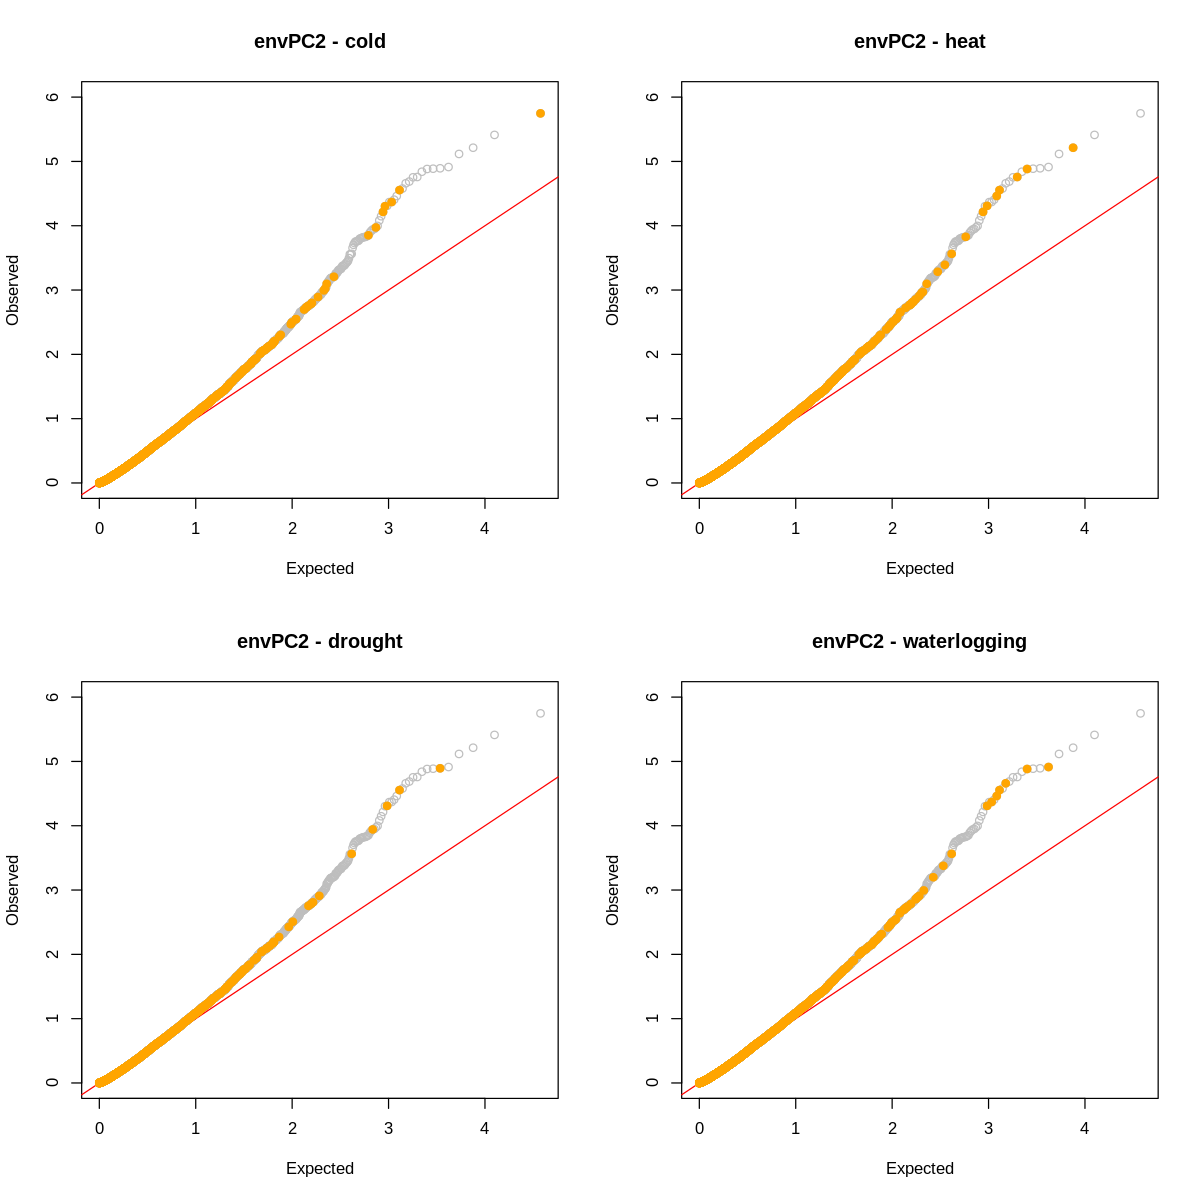

In [726]:
options(repr.plot.width=10, repr.plot.height=10)
exptd = -log10(ppoints(nrow(testRes_envPC2_v2)))
par(mfrow = c(2,2))
plot(exptd,sort(testRes_envPC2_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC2 - cold (2,212)",ylim = c(0,6))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%coldResponsiveGenes],
       sort(testRes_envPC2_v2$logp[testRes_envPC2_v2$OG%in%coldResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)
plot(exptd,sort(testRes_envPC2_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC2 - heat (2,874)",ylim = c(0,6))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%heatResponsiveGenes],
       sort(testRes_envPC2_v2$logp[testRes_envPC2_v2$OG%in%heatResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)
plot(exptd,sort(testRes_envPC2_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC2 - drought (1,292)",ylim = c(0,6))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%droughtResponsiveGenes],
       sort(testRes_envPC2_v2$logp[testRes_envPC2_v2$OG%in%droughtResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)
plot(exptd,sort(testRes_envPC2_v2$logp,decreasing = T),
     xlab = "Expected",ylab ="Observed",col ="grey",main = "envPC2 - waterlogging (2,524)",ylim = c(0,6))
abline(a = 0, b=1,col = "red")
points(exptd[testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%waterResponsiveGenes],
       sort(testRes_envPC2_v2$logp[testRes_envPC2_v2$OG%in%waterResponsiveGenes],decreasing = T),
       col ="orange",pch = 19)

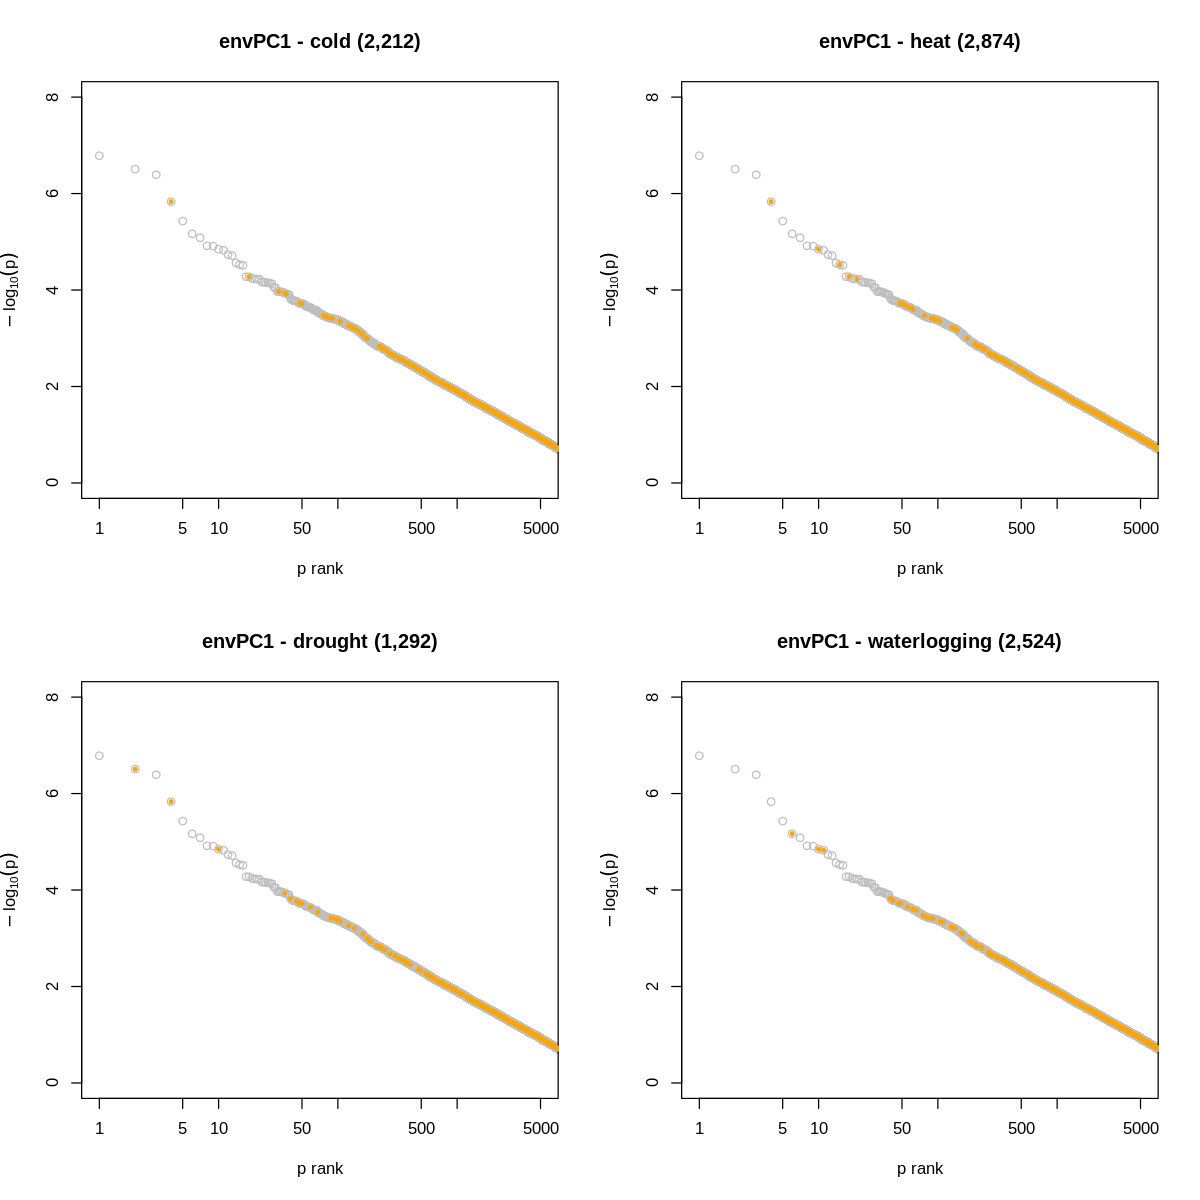

In [805]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,2))
plot(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC1 - cold (2,212)",ylim = c(0,8))
points(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%coldResponsiveGenes,"orange",NA),pch = 19)
plot(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC1 - heat (2,874)",ylim = c(0,8))
points(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%heatResponsiveGenes,"orange",NA),pch = 19)
plot(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC1 - drought (1,292)",ylim = c(0,8))
points(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%droughtResponsiveGenes,"orange",NA),pch = 19)
plot(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC1 - waterlogging (2,524)",ylim = c(0,8))
points(1:nrow(testRes_envPC1_v2),sort(testRes_envPC1_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC1_v2$OG[order(testRes_envPC1_v2$p)]%in%waterResponsiveGenes,"orange",NA),pch = 19)


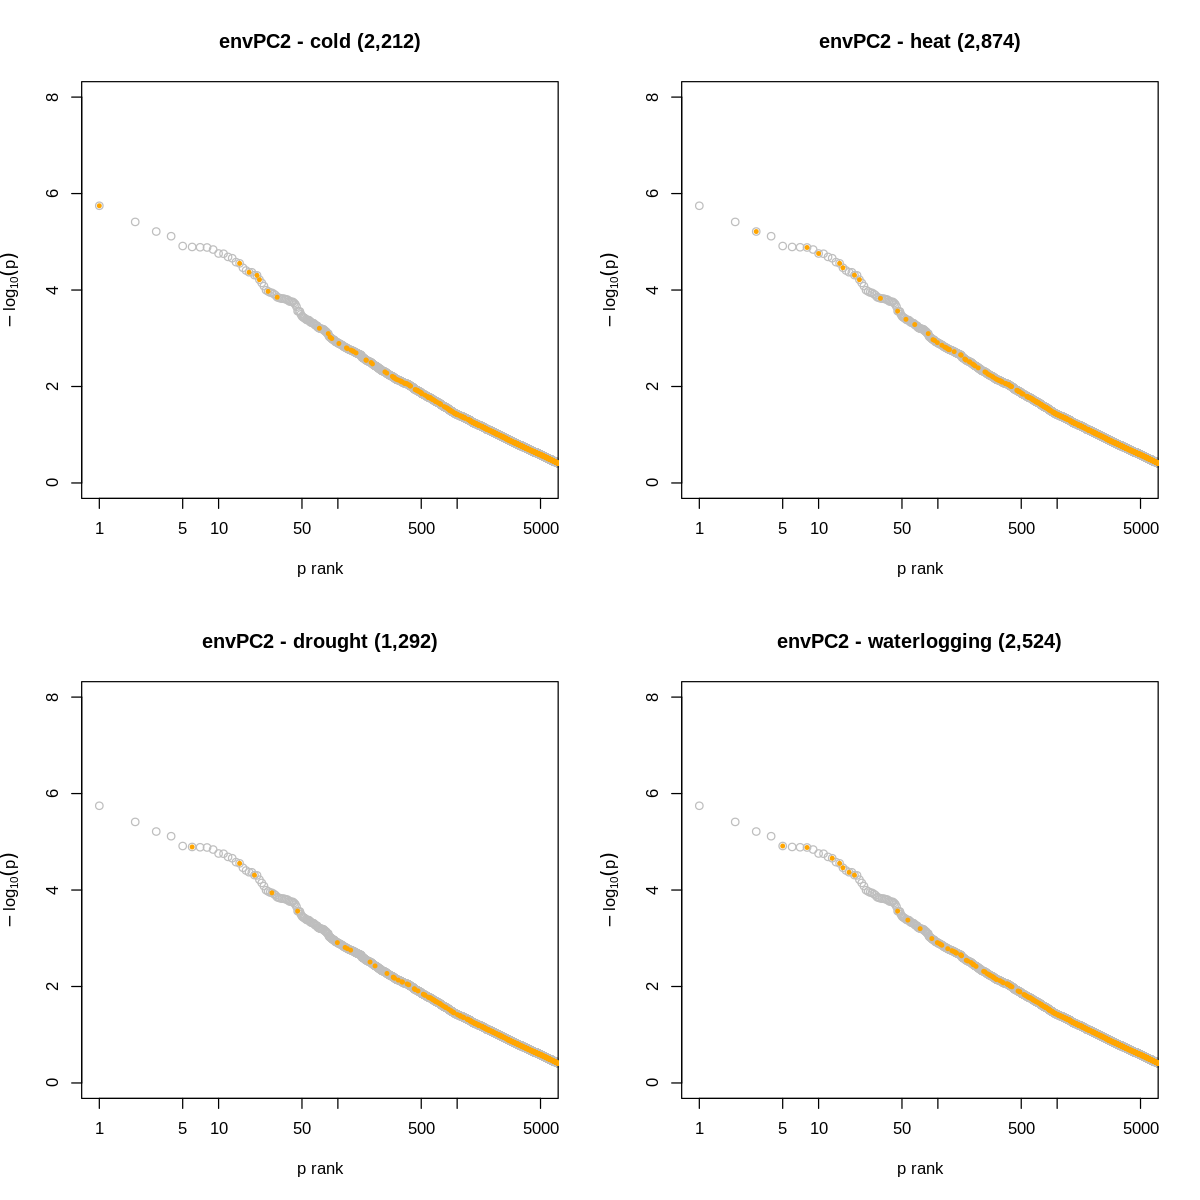

In [806]:
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(2,2))
plot(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC2 - cold (2,212)",ylim = c(0,8))
points(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%coldResponsiveGenes,"orange",NA),pch = 19)
plot(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC2 - heat (2,874)",ylim = c(0,8))
points(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%heatResponsiveGenes,"orange",NA),pch = 19)
plot(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC2 - drought (1,292)",ylim = c(0,8))
points(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%droughtResponsiveGenes,"orange",NA),pch = 19)
plot(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),log = 'x',xlim = c(1,5000),
     xlab = "p rank",ylab =expression(-log[10](p)),col ="grey",main = "envPC2 - waterlogging (2,524)",ylim = c(0,8))
points(1:nrow(testRes_envPC2_v2),sort(testRes_envPC2_v2$logp,decreasing = T),cex = .5,
       col =ifelse(testRes_envPC2_v2$OG[order(testRes_envPC2_v2$p)]%in%waterResponsiveGenes,"orange",NA),pch = 19)


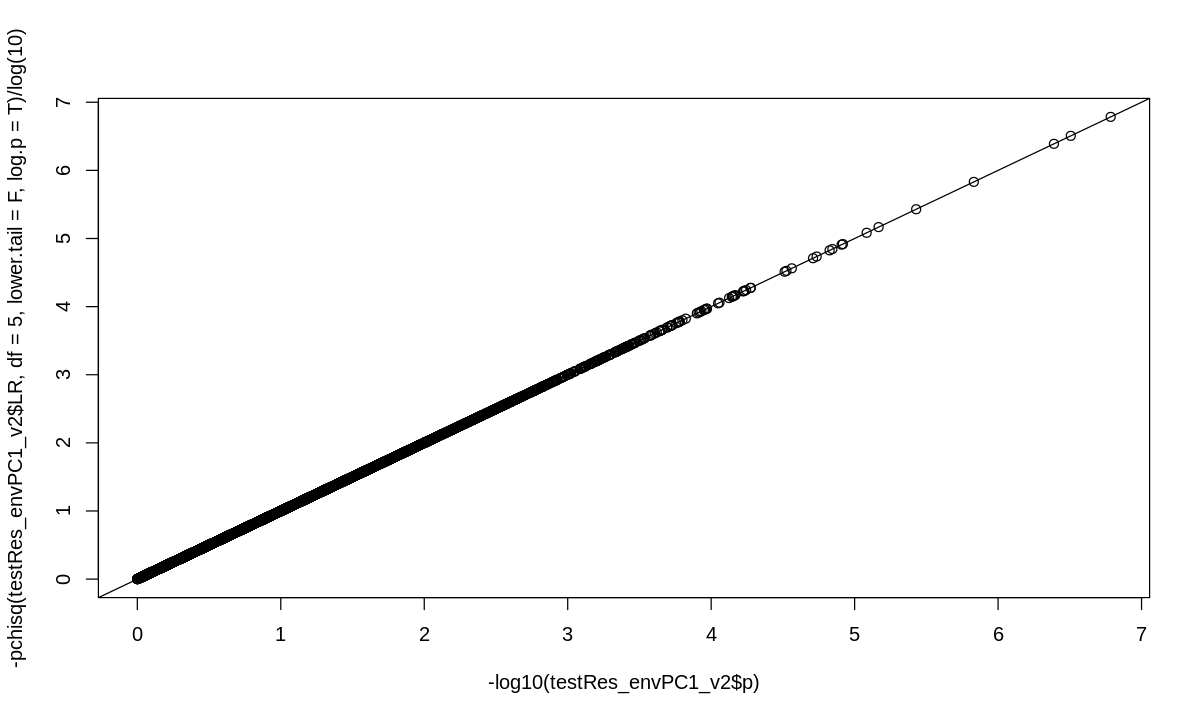

In [428]:
plot(-log10(testRes_envPC1_v2$p),-pchisq(testRes_envPC1_v2$LR,df = 5,lower.tail = F,log.p = T)/log(10))
abline(a =0, b=1)

In [486]:
testRes_envPC1_v2$geneClass = rep("0",length(testRes_envPC1_v2$OG))
testRes_envPC1_v2$geneClass[testRes_envPC1_v2$OG%in%coldResponsiveGenes]="1"
testRes_envPC1_v2$geneClass[testRes_envPC1_v2$OG%in%heatResponsiveGenes]="2"
testRes_envPC1_v2$geneClass[testRes_envPC1_v2$OG%in%droughtResponsiveGenes]="3"
testRes_envPC1_v2$geneClass[testRes_envPC1_v2$OG%in%waterResponsiveGenes]="4"
testRes_envPC1_v2$geneClass[testRes_envPC1_v2$OG%in%unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))])]="5"

testRes_envPC1_v2$logp = -log10(testRes_envPC1_v2$p)

In [554]:
testRes_envPC2_v2$geneClass = rep("0",length(testRes_envPC2_v2$OG))
testRes_envPC2_v2$geneClass[testRes_envPC2_v2$OG%in%coldResponsiveGenes]="1"
testRes_envPC2_v2$geneClass[testRes_envPC2_v2$OG%in%heatResponsiveGenes]="2"
testRes_envPC2_v2$geneClass[testRes_envPC2_v2$OG%in%droughtResponsiveGenes]="3"
testRes_envPC2_v2$geneClass[testRes_envPC2_v2$OG%in%waterResponsiveGenes]="4"
testRes_envPC2_v2$geneClass[testRes_envPC2_v2$OG%in%unique(unlist(envResponsiveGenes)[duplicated(unlist(envResponsiveGenes))])]="5"

testRes_envPC2_v2$logp = -log10(testRes_envPC2_v2$p)

In [472]:
library(ggplot2)
library(ggridges)

Picking joint bandwidth of 0.793



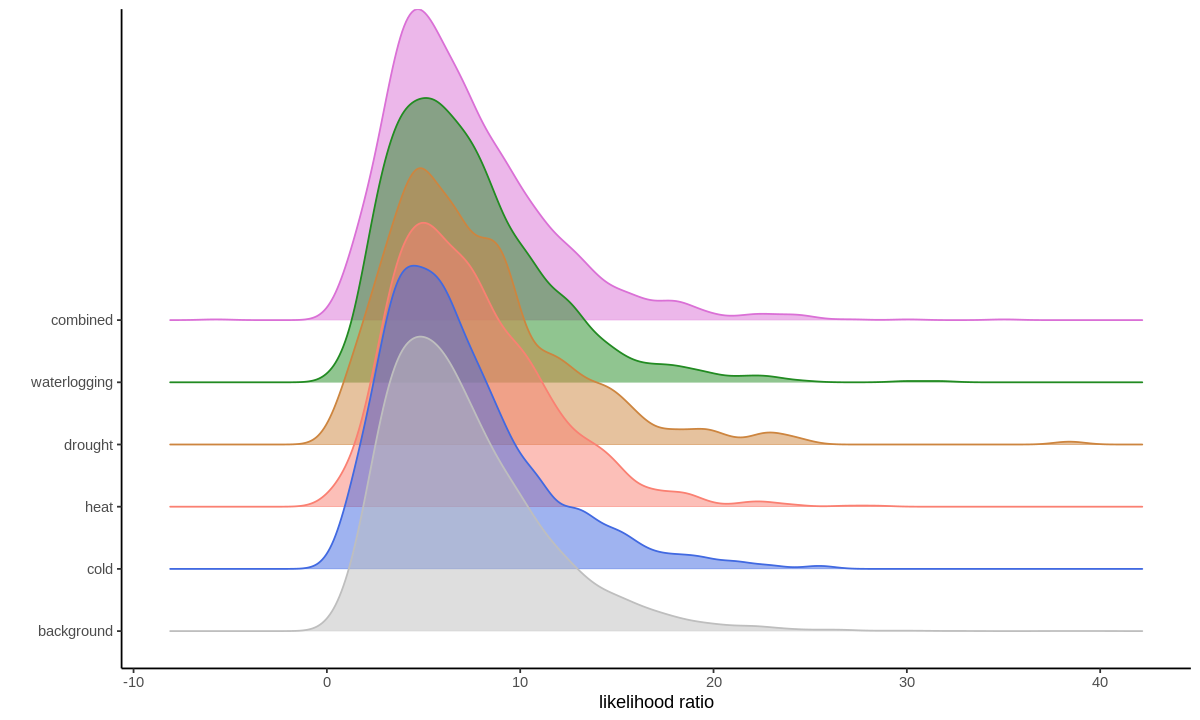

In [648]:
ggplot(testRes_envPC1_v2, aes(x = LR, y = geneClass,fill = geneClass,color = geneClass)) +
  geom_density_ridges_gradient(scale = 5, rel_min_height = 0) + 
#   scale_fill_gradient2(name = "Likelihood ratio", low = "orange", mid = "grey90", high = "white", 
#                        midpoint = median(testRes_envPC1_v2$LR,na.rm = T)) +
  scale_color_manual(values = c("grey","royalblue","salmon","peru",'forestgreen',"orchid"))+
  scale_fill_manual(values = scales::alpha(c("grey","royalblue","salmon","peru",'forestgreen',"orchid"),.5))+
  scale_y_discrete(labels=c("0" = "background","1" = "cold", "2" = "heat",
                            "3" = "drought","4" = "waterlogging","5" = "combined"))+
  xlab("likelihood ratio") +
  ylab("") +
#   xlim(c(-3,2)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

In [606]:
tapply(testRes_envPC1_v2$logp,testRes_envPC1_v2$geneClass,function(x) quantile(x,.995))

0        1        2        3        4        5 
3.342768 3.221394 3.361169 3.619490 3.417124 3.670484

Picking joint bandwidth of 0.678



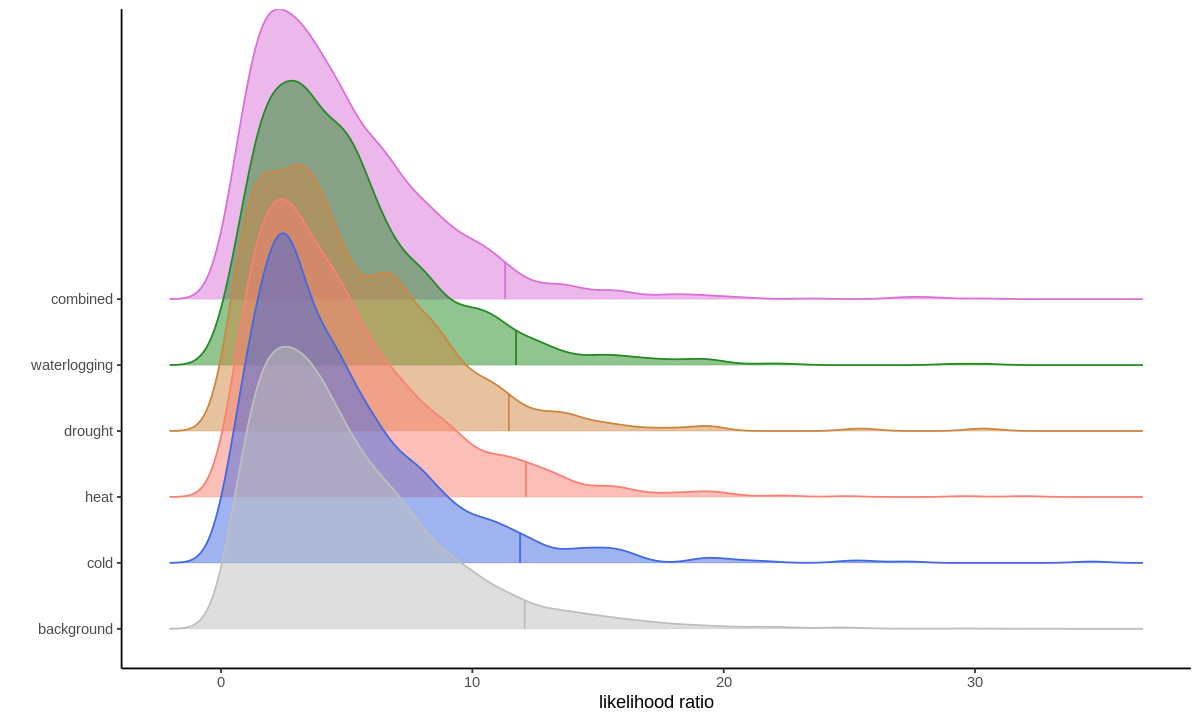

In [625]:
ggplot(testRes_envPC2_v2, aes(x = LR, y = geneClass,fill = geneClass,color = geneClass)) +
  geom_density_ridges_gradient(scale = 5, rel_min_height = 0,quantiles = 0.95, quantile_lines = T) + 
#   scale_fill_gradient2(name = "Likelihood ratio", low = "orange", mid = "grey90", high = "white", 
#                        midpoint = median(testRes_envPC1_v2$LR,na.rm = T)) +
  scale_color_manual(values = c("grey","royalblue","salmon","peru",'forestgreen',"orchid"))+
  scale_fill_manual(values = scales::alpha(c("grey","royalblue","salmon","peru",'forestgreen',"orchid"),.5))+
  scale_y_discrete(labels=c("0" = "background","1" = "cold", "2" = "heat",
                            "3" = "drought","4" = "waterlogging","5" = "combined"))+
  xlab("likelihood ratio") +
  ylab("") +
#   xlim(c(-3,2)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

In [624]:
tapply(testRes_envPC2_v2$LR,testRes_envPC2_v2$geneClass,function(x) quantile(x,.999))

0        1        2        3        4        5 
25.32559 28.33862 27.37789 28.04018 28.15256 28.18423

In [526]:
?geom_density_ridges_gradient

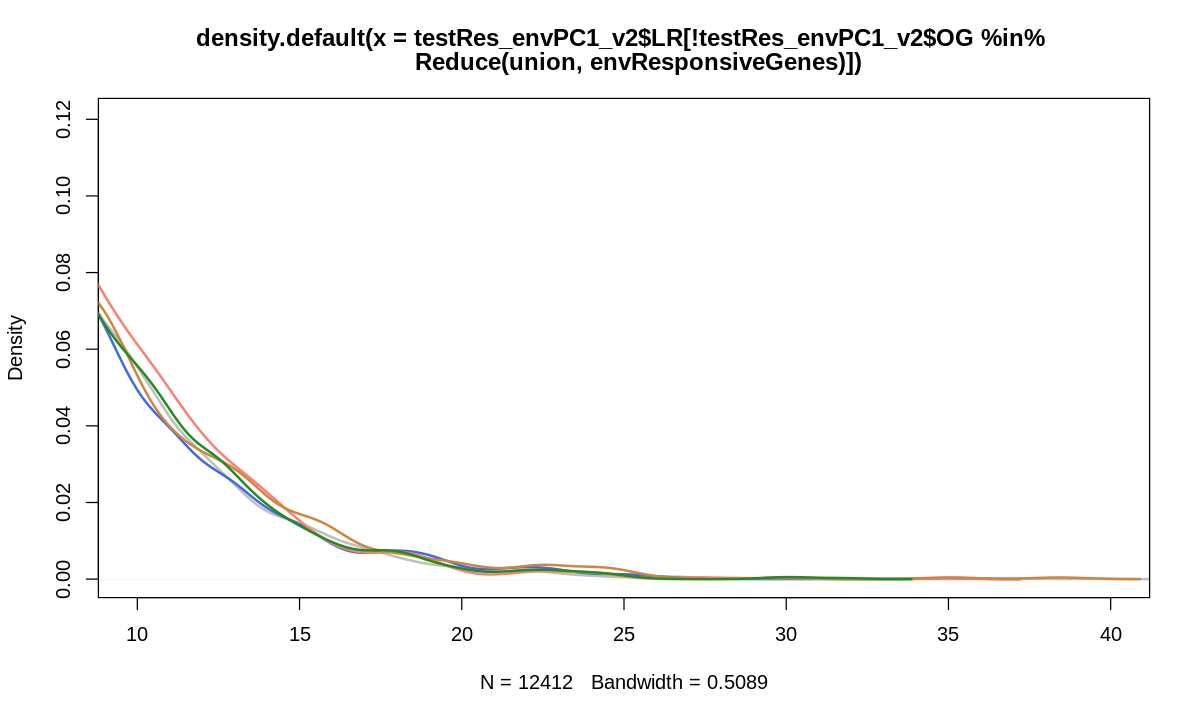

In [647]:
plot(density(testRes_envPC1_v2$LR[!testRes_envPC1_v2$OG%in%Reduce(union,envResponsiveGenes)]),
     col = "grey",lwd =2,xlim = c(10,40))
points(density(testRes_envPC1_v2$LR[testRes_envPC1_v2$OG%in%coldResponsiveGenes]),
       type = 'l',col = "royalblue",lwd =2)
points(density(testRes_envPC1_v2$LR[testRes_envPC1_v2$OG%in%heatResponsiveGenes]),
       type = 'l',col = "salmon",lwd =2)
points(density(testRes_envPC1_v2$LR[testRes_envPC1_v2$OG%in%droughtResponsiveGenes]),
       type = 'l',col = "peru", lwd = 2)
points(density(testRes_envPC1_v2$LR[testRes_envPC1_v2$OG%in%waterResponsiveGenes]),
       type = 'l',col = "forestgreen", lwd = 2)

In [517]:
t.test(-log10(testRes_envPC1_v2$p[!testRes_envPC1_v2$OG%in%Reduce(union,envResponsiveGenes)]),
       -log10(testRes_envPC1_v2$p[testRes_envPC1_v2$OG%in%waterResponsiveGenes]))


	Welch Two Sample t-test

data:  -log10(testRes_envPC1_v2$p[!testRes_envPC1_v2$OG %in% Reduce(union, envResponsiveGenes)]) and -log10(testRes_envPC1_v2$p[testRes_envPC1_v2$OG %in% waterResponsiveGenes])
t = -1.0636, df = 2975.6, p-value = 0.2876
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.04440424  0.01317141
sample estimates:
mean of x mean of y 
0.7245721 0.7401885 


In [353]:
summary(-log10(testRes_envPC1_v2$p))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.2836  0.5600  0.7321  0.9950  6.7848 

In [227]:
which(t(sapply(DEG_trsl_list,function(x){
    p = fisher.test(cont_table(envPC1_candidate,background,x),alternative = "greater")$p
    or = fisher.test(cont_table(envPC1_candidate,background,x),alternative = "greater")$estimate
    return(c(or,p))
}))[,2]<0.05)


output/candidateGenes/Sitalica_312_v2_coldDEGs.txt 
                                                29 
         output/candidateGenes/Tae_heat_DaRos_2023 
                                                34 
       output/candidateGenes/Zma_drought_Zeng_2009 
                                                40

In [178]:
which(t(sapply(DEG_trsl_list,function(x){
    p = fisher.test(cont_table(envPC2_candidate,background,x),alternative = "greater")$p
    or = fisher.test(cont_table(envPC2_candidate,background,x),alternative = "greater")$estimate
    return(c(or,p))
}))[,2]<0.05)


[1] 25 27